# `sqc` 传感仿真：完整示例

本 notebook 用重构后的 `sqc.*` API 演示时变磁场传感的各条科研主线。全书按三条主线编组：

- **第一部分 · 波形重建** —— 已完成，可端到端运行。传感未知时变磁通并重建其波形。
- **第二部分 · 频率标定** —— 骨架，待补。
- **第三部分 · 预失真** —— 骨架，待补。

顶层 API 的约定：每条协议是一个独立的 `*Experiment` 类，重建是独立的
`*Reconstruction` 类；所有时间轴从全局 `sqc.config.CONFIG` 派生（`dt = 1/sample_rate`）。
实验返回统一的 `ExperimentResult`（`.data` / `.axes` / `.metadata`）。

# 第一部分 · 波形重建

## A0. 环境、全局配置与辅助函数

先导入依赖、打印 `CONFIG` 的关键量，并定义两个贯穿全书的辅助函数：`make_qubit`
（统一 Transmon 默认参数）和 `plot_true_vs_rec`（重建对比图）。所有 sqc API 调用
在各节仍显式书写。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sqc.config import CONFIG
from sqc.devices.transmon import TransmonQubit
from sqc.control.flux_signal import FluxSignal

# 默认 Transmon：EC/EJ 以 rad·GHz 传入（构造签名要求角频率单位）。
_EC = 0.2 * 2 * np.pi
_EJ = 10.0 * 2 * np.pi


def make_qubit(flux=0.0, n_levels=2, EC=_EC, EJ=_EJ, T1=100.0e3, T2=50.0e3, **kw):
    """统一的 Transmon 工厂：只有 flux/n_levels 常变，其余取全书默认。"""
    return TransmonQubit(EC=EC, EJ=EJ, T1=T1, T2=T2, flux=flux,
                         n_levels=n_levels, **kw)


def plot_true_vs_rec(t_true, B_true, t_rec, B_rec, title="", ax=None):
    """画「原始 B vs 重建 B」对比。B_rec 可为 ndarray 或 FluxSignal。
    颜色取自全局风格别名 C_REF / C_REC（见下方风格设定 cell）。"""
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))
    ax.plot(t_true, B_true, "--", color=C_REF, lw=1.4, label="Original $B$")
    ax.plot(t_rec, B_rec, color=C_REC, lw=1.8, label="Reconstructed $B$")
    ax.set_xlabel("t (ns)"); ax.set_ylabel("$B$ (arb.)")
    ax.set_title(title); ax.legend()
    return ax


print(f"AWG sample_rate = {CONFIG.awg.sample_rate} GSa/s  ->  dt = {CONFIG.awg.dt} ns")
print(f"t_rabi  : N={len(CONFIG.pulse.t_rabi)}")
print(f"tau_list: N={len(CONFIG.pulse.tau_list)}")
print(f"Transmon defaults: EC/h={CONFIG.transmon.EC} GHz, EJ/h={CONFIG.transmon.EJ} GHz")

AWG sample_rate = 2.0 GSa/s  ->  dt = 0.5 ns
t_rabi  : N=20
tau_list: N=500
Transmon defaults: EC/h=0.2 GHz, EJ/h=15.0 GHz


In [2]:
# ── 可视化风格设定（Nature 论文级 · 低饱和度）────────────────────────────
# 全局 rcParams + 低饱和度定性调色板，供全书所有图统一取用。
# 放在此处（A0 之后），后续所有 cell 沿用，保证全书视觉统一。
import matplotlib as mpl
from cycler import cycler

# 低饱和度定性调色板（seaborn "muted/deep" 风格；刻意避开高饱和原色）
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52",
           "#8172B3", "#64B5CD", "#CCB974", "#937860"]
# 语义别名（正文按含义引用，避免散落的 hex）
C_REF = "#2F2F2F"        # 真值 / 原始 / 理想参考：中性深灰（替代刺眼的纯黑纯红）
C_DATA = PALETTE[0]      # 主测量数据（沉稳蓝）
C_REC = PALETTE[3]       # 重建 / 强调（低饱和暗红）
CMAP_SEQ = "cividis"     # 连续色图：感知均匀、色盲友好、低饱和

mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300,
    "figure.facecolor": "white", "savefig.facecolor": "white",
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
    "axes.titleweight": "medium", "axes.titlepad": 8,
    "axes.linewidth": 0.8, "axes.edgecolor": "#4D4D4D",
    "axes.facecolor": "white", "axes.axisbelow": True, "axes.grid": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.prop_cycle": cycler(color=PALETTE),
    "grid.color": "#B0B0B0", "grid.linewidth": 0.6, "grid.alpha": 0.35,
    "lines.linewidth": 1.8, "lines.markersize": 5, "lines.markeredgewidth": 0,
    "xtick.direction": "out", "ytick.direction": "out",
    "xtick.color": "#4D4D4D", "ytick.color": "#4D4D4D",
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "legend.frameon": False, "legend.fontsize": 9,
})
print(f"风格已设定：{len(PALETTE)} 色低饱和度调色板 · Nature 规范")

风格已设定：8 色低饱和度调色板 · Nature 规范


## A1. Rabi 振荡 — `RabiExperiment`

热身。施加恒定振幅驱动脉冲，测量激发态布居 $p_e(t)$，确立 `*Experiment` 的调用模式。
注意 `RabiExperiment.run()` 直接返回 QuTiP `Result`（用 `.expect[0]`），是唯一不返回
`ExperimentResult` 的实验。

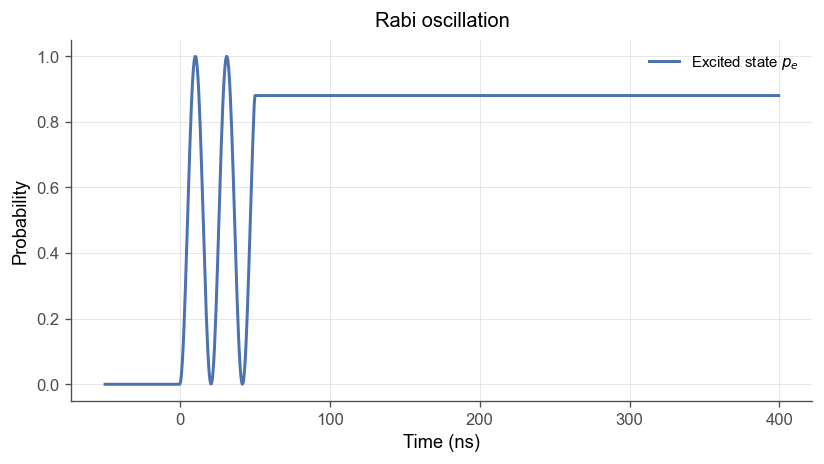

In [3]:
from sqc.experiments.rabi import RabiExperiment

qubit = make_qubit(flux=0.0)
# t_rabi 只设定驱动脉冲包络宽度；测量始终在统一全局时间轴 CONFIG.pulse.t_global 上。
rabi_result = RabiExperiment(qubit=qubit, t_rabi=CONFIG.pulse.make_time(0, 50), omega_rabi=0.3).run()
t_axis = CONFIG.pulse.t_global

plt.figure(figsize=(7, 4))
plt.plot(t_axis, rabi_result.expect[0], label="Excited state $p_e$")
plt.xlabel("Time (ns)"); plt.ylabel("Probability")
plt.title("Rabi oscillation"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## A2. Ramsey 干涉 — `RamseyExperiment` + `RamseyReconstruction`

$\pi/2 - \tau - \pi/2$ 序列测量自由演化期间积累的相位，由相位演化反推磁场 $B(t)$。qubit 偏置到磁通敏感点（$d\omega/d\Phi$ 较大处）以提高灵敏度。

> 自由演化并非从全局 $t=0$ 开始，而是在首个 $\pi/2$ 脉冲之后。因此用 `reconstruct_with_time()` 获取补偿了该偏移的绝对时间轴（否则重建波形会整体左移约一个 $\pi/2$ 脉宽）；`reconstruct()` 仍返回 `np.ndarray`。

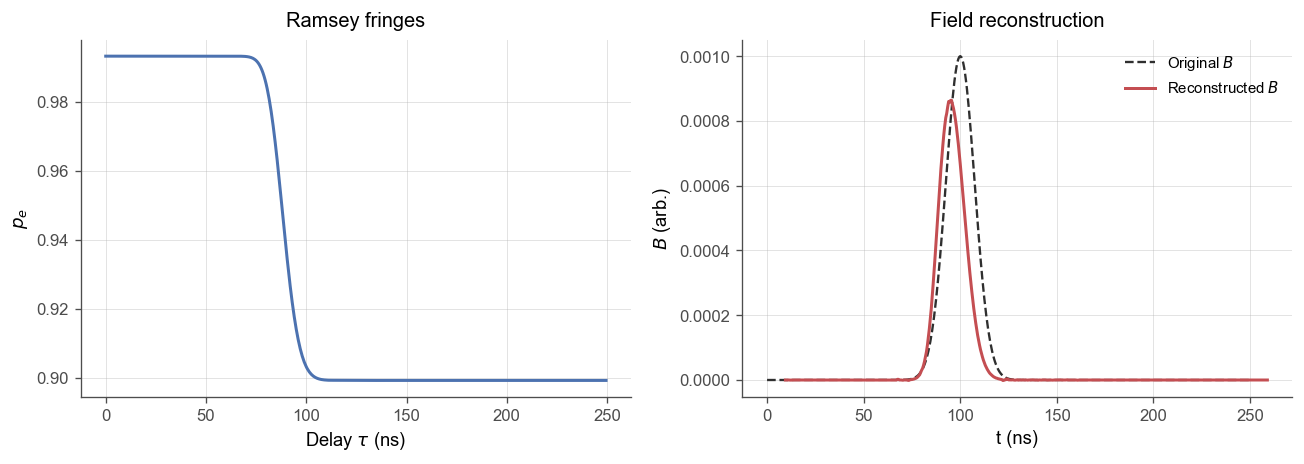

In [4]:
from sqc.experiments.ramsey import RamseyExperiment
from sqc.reconstruction.ramsey import RamseyReconstruction

qubit = make_qubit(flux=0.25)          # 敏感工作点
result = RamseyExperiment(qubit=qubit).run()   # 默认正弦 flux 测试信号

rec = RamseyReconstruction(qubit=qubit, method="unwrap")
# reconstruct_with_time 补偿首个 π/2 脉宽偏移，返回与真实 B(t) 对齐的绝对时间轴
t_rec, B_rec = rec.reconstruct_with_time(result)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(result.axes["tau"], result.data["p_e"], color=C_DATA)
axes[0].set(xlabel=r"Delay $\tau$ (ns)", ylabel=r"$p_e$", title="Ramsey fringes")
plot_true_vs_rec(result.axes["t_flux"], result.data["flux_samples"],
                 t_rec, B_rec, title="Field reconstruction", ax=axes[1])
fig.tight_layout(); plt.show()

## A3. 瞬态磁场感测 — `TransientSensingExperiment` + `TransientReconstruction`

**波形重建的核心协议**。滑动的短 Ramsey 控制脉冲扫过磁场信号，测得 $\Delta p_e$，再用
Wiener 反卷积从中还原 $B(t)$。重建器还提供 `hammerstein`（非线性校正）与 `lm`
（Levenberg–Marquardt）两种方法。

注意返回类型：`wiener` / `hammerstein` 返回 `FluxSignal`（有 `.t_list` / `.signal`），
而 `method="lm"` 返回 `(FluxSignal, dict)` 元组，需解包。

Sliding measurement with 439 samples took 8.01 seconds


Sliding measurement with 439 samples took 4.10 seconds


C:\Users\21034\anaconda3\envs\qutip-env\Lib\site-packages\qutip\core\coefficient.py:192: RuntimeWarning: invalid value encountered in divide
  return coefficient_builders[type_](base, **kwargs)


Kernel computation took 0.28 seconds


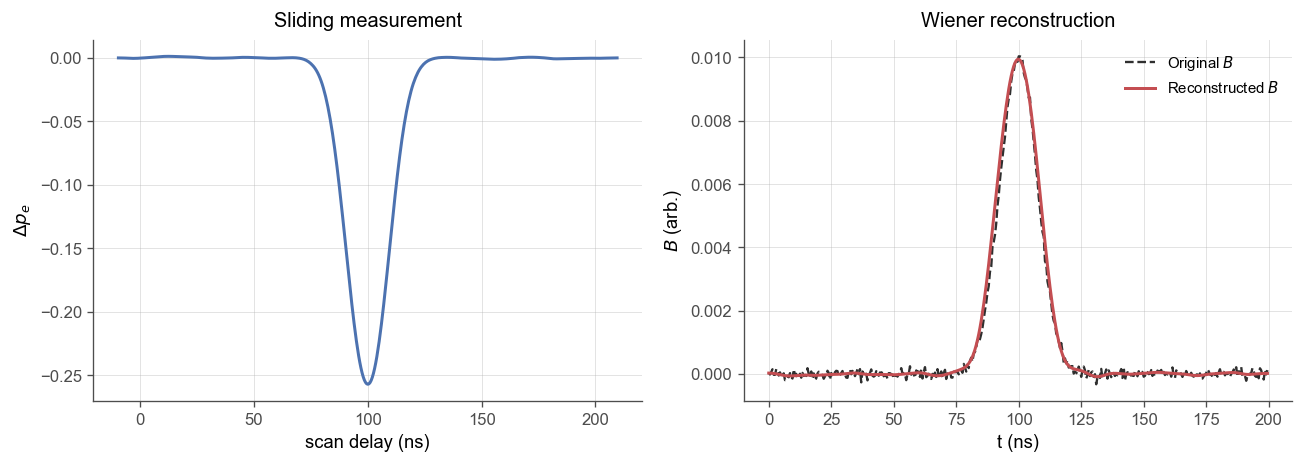

In [5]:
from sqc.experiments.transient import TransientSensingExperiment
from sqc.reconstruction.transient import TransientReconstruction

qubit = make_qubit(flux=0.9553)
trans_result = TransientSensingExperiment(qubit=qubit).run()  # 默认 type-4 冲激信号
kernel = trans_result.data["kernel"]

# Wiener 反卷积（核心重建方法）
B_wiener = TransientReconstruction(
    method="wiener", lambda_reg=5
).reconstruct(trans_result, kernel=kernel)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(trans_result.axes["scan"], trans_result.data["delta_p"], color=C_DATA)
axes[0].set(xlabel="scan delay (ns)", ylabel=r"$\Delta p_e$", title="Sliding measurement")
plot_true_vs_rec(trans_result.axes["t_flux"], trans_result.data["flux_samples"],
                 B_wiener.t_list, B_wiener.signal,
                 title="Wiener reconstruction", ax=axes[1])
fig.tight_layout(); plt.show()

## A4. Cryoscope 完整流程 — 标定 → 测量 → 重建

Cryoscope 用 IQ Ramsey 读相测量磁通脉冲。流程分三步：**标定** $\varphi(h)$ 响应表 →
**测量** 截断脉冲的 $\varphi(t_d)$ → **重建** 反演出 $h(t)$。这里在磁通敏感点
（`flux=0.25`）工作，使 $\varphi(h)$ 单调、可正确反演符号。

我们对比两种反演：`inversion="calibration"`（查标定表）与 `inversion="response"`
（用 qubit 解析色散关系直接反演）。`.reconstruct()` 返回 `FluxSignal`。

trunc_list: [104.5 104.  103.5 103.  102.5 102.  101.5 101.  100.5 100.   99.5  99.
  98.5  98.   97.5  97.   96.5  96.   95.5  95.   94.5  94.   93.5  93.
  92.5  92.   91.5  91.   90.5  90.   89.5  89.   88.5  88.   87.5  87.
  86.5  86.   85.5  85.   84.5  84.   83.5  83.   82.5  82.   81.5  81.
  80.5  80.   79.5  79.   78.5  78.   77.5  77.   76.5  76.   75.5  75.
  74.5  74.   73.5  73.   72.5  72.   71.5  71.   70.5  70.   69.5  69.
  68.5  68.   67.5  67.   66.5  66.   65.5  65.   64.5  64.   63.5  63.
  62.5  62.   61.5  61.   60.5  60.   59.5  59.   58.5  58.   57.5  57.
  56.5  56.   55.5  55.   54.5  54.   53.5  53.   52.5  52.   51.5  51.
  50.5  50.   49.5  49.   48.5  48.   47.5  47.   46.5  46.   45.5  45.
  44.5  44.   43.5  43.   42.5  42.   41.5  41.   40.5  40.   39.5  39.
  38.5  38.   37.5  37.   36.5  36.   35.5  35.   34.5  34.   33.5  33.
  32.5  32.   31.5  31.   30.5  30.   29.5  29.   28.5  28.   27.5  27.
  26.5  26.   25.5  25.   24.5  24.   23.5  23.   22

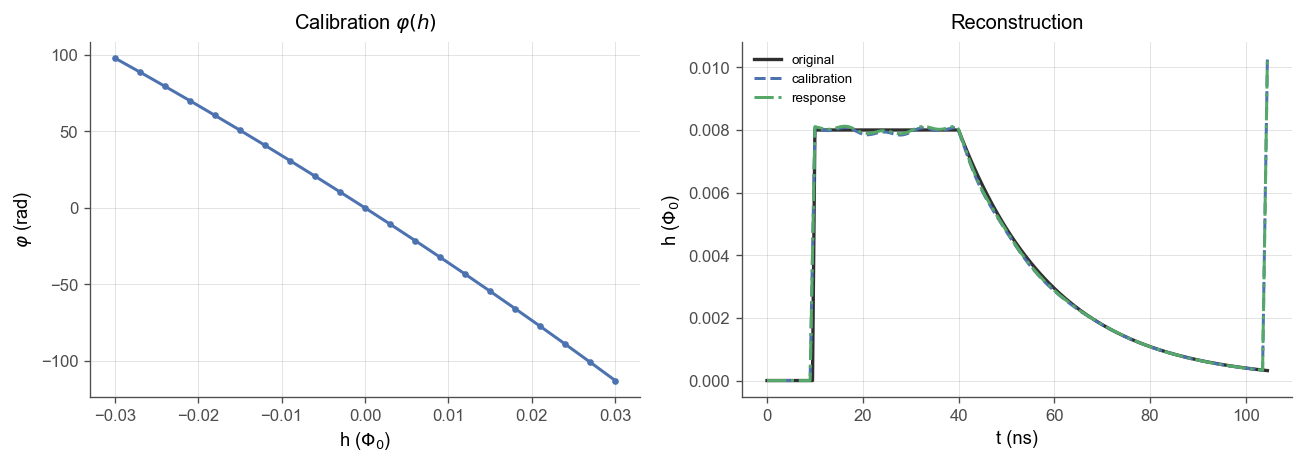

In [6]:
from sqc.experiments.cryoscope import CryoscopeExperiment
from sqc.reconstruction.cryoscope import CryoscopeCalibration, CryoscopeReconstruction

qubit = make_qubit(flux=0.25, n_levels=3)
tau = 105.0

# 测试信号：方波平台 + 指数拖尾
t_list = CONFIG.pulse.make_time(0, 105)
sig = np.zeros(len(t_list))
sig[(t_list >= 10) & (t_list <= 40)] = 0.008
sig[t_list > 40] = 0.008 * np.exp(-(t_list[t_list > 40] - 40) / 20)
test_flux = FluxSignal(type=8, t_list=t_list, signal=sig)

# --- Step 1: 标定 phi(h) ---
cal_table = CryoscopeCalibration(
    qubit=qubit, h_list=np.linspace(-0.03, 0.03, 21), tau=tau
).calibrate()

# --- Step 2: 测量（显式传 trunc_list，避免默认切片的警告）---
trunc_list = CONFIG.pulse.make_time(0, 105)[::-1]
meas = CryoscopeExperiment(qubit=qubit, flux_signal=test_flux,
                           tau=tau, trunc_list=trunc_list).run()

# --- Step 3: 重建(两种反演) ---
h_cal = CryoscopeReconstruction(calibration=cal_table, tau=tau,
                                inversion="calibration").reconstruct(meas)
h_resp = CryoscopeReconstruction(qubit=qubit, tau=tau,
                                 inversion="response").reconstruct(meas)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(cal_table.inputs, cal_table.outputs, "o-", color=C_DATA, ms=4)
axes[0].set(xlabel="h ($\\Phi_0$)", ylabel="$\\varphi$ (rad)", title="Calibration $\\varphi(h)$")
axes[1].plot(test_flux.t_list, test_flux.signal, "-", color=C_REF, lw=2, label="original")
axes[1].plot(h_cal.t_list, h_cal.signal, "--", color=PALETTE[0], label="calibration")
axes[1].plot(h_resp.t_list, h_resp.signal, "-.", color=PALETTE[2], label="response")
axes[1].set(xlabel="t (ns)", ylabel="h ($\\Phi_0$)", title="Reconstruction")
axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

## A5. 延迟 Ramsey 拖尾重建 — `DelayRamseyExperiment` + `DelayRamseyReconstruction`

**磁通脉冲拖尾测量（预畸变主线的输入）**。在下降沿后不同延迟 $t_d$ 处插入一段自由演化窗口读相，标定 $\varphi(z)$ 后反演出拖尾 $\Phi(t)$。方法测得的是自由演化窗口（宽 $\tau_R$）内的**平均** flux，故与 $\tau_R$ 移动平均参考对比。`.reconstruct()` 返回 `FluxSignal`。

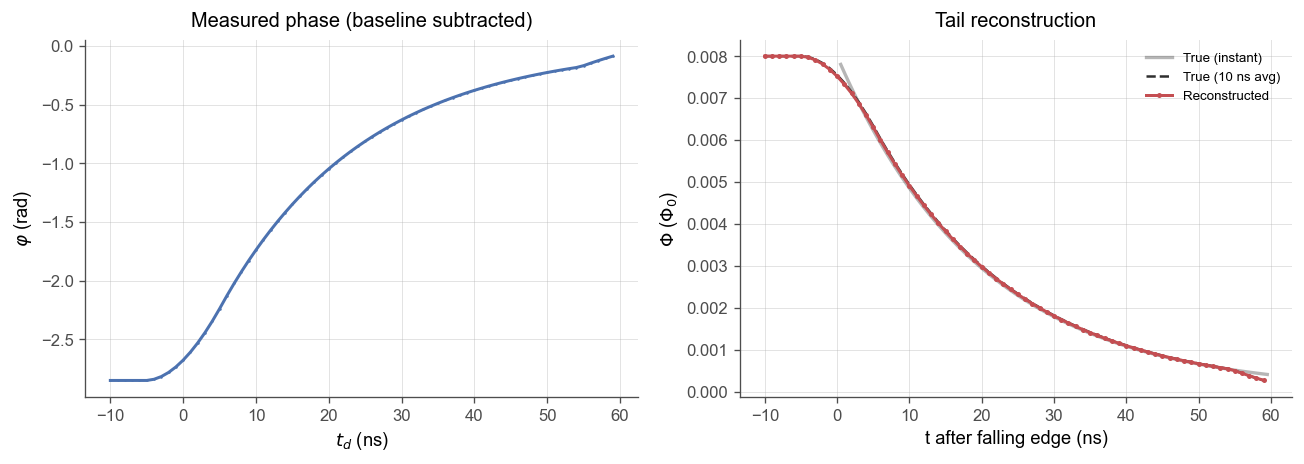

RMSE vs 10-ns moving avg = 0.000017 Phi0


In [7]:
from sqc.experiments.delay_ramsey import DelayRamseyExperiment
from sqc.reconstruction.delay_ramsey import (
    DelayRamseyCalibration, DelayRamseyReconstruction,
)

qubit = make_qubit(flux=0.25)
tau_R = 10.0

# 测试信号：方波平台 + 指数拖尾（下降沿在 t=40 ns）
t_list = CONFIG.pulse.make_time(0, 100)
sig = np.zeros(len(t_list))
sig[(t_list >= 10) & (t_list <= 40)] = 0.008
sig[t_list > 40] = 0.008 * np.exp(-(t_list[t_list > 40] - 40) / 20)
test_flux = FluxSignal(type=8, t_list=t_list, signal=sig)

# --- Step 1: 标定 φ(z)（内含 τ_R 窗口平均 + Transmon 色散）---
cal_table = DelayRamseyCalibration(
    qubit=qubit, z_list=np.linspace(-0.010, 0.010, 41),
    tau_R=tau_R, t_rabi=np.linspace(0, 10, 20),
).calibrate()

# --- Step 2: 测量（run_baseline=True 消除 arctan2 零偏）---
t_d_list = CONFIG.pulse.make_time(-10, 60)[::2]
meas = DelayRamseyExperiment(
    qubit=qubit, flux_signal=test_flux, t_d_list=t_d_list, tau_R=tau_R,
    t_rabi=np.linspace(0, 10, 20), t_fall=40.0, run_baseline=True,
).run()

# --- Step 3: 重建拖尾 ---
tail_flux = DelayRamseyReconstruction(
    inversion="calibration", calibration=cal_table,
).reconstruct(meas)

# τ_R 移动平均参考（方法测的是自由演化窗口内的平均 flux）
tail_avg = np.array([
    np.mean([float(test_flux.value_at(40 + td + t))
             for t in np.linspace(-tau_R / 2, tau_R / 2, 41)])
    for td in t_d_list
])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(meas.axes["t_d"], meas.data["varphi"], ".-", color=C_DATA, ms=3)
axes[0].set(xlabel="$t_d$ (ns)", ylabel=r"$\varphi$ (rad)",
            title="Measured phase (baseline subtracted)")
axes[1].plot(t_list[t_list > 40] - 40, sig[t_list > 40], "-", color=C_REF, lw=2,
             alpha=0.35, label="True (instant)")
axes[1].plot(t_d_list, tail_avg, "--", color=C_REF, lw=1.5, label=f"True ({tau_R:.0f} ns avg)")
axes[1].plot(tail_flux.t_list, tail_flux.signal, "o-", color=C_REC,
             ms=3, label="Reconstructed")
axes[1].set(xlabel="t after falling edge (ns)", ylabel=r"$\Phi$ ($\Phi_0$)",
            title="Tail reconstruction")
axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()
print(f"RMSE vs {tau_R:.0f}-ns moving avg = "
      f"{np.sqrt(np.mean((tail_flux.signal - tail_avg) ** 2)):.6f} Phi0")

## A6. $\pi$ 脉冲补偿拖尾重建 — `PiPulseCompensationExperiment` + `PiPulseCompReconstruction`

另一条拖尾测量路线：在拖尾上加补偿磁通 $z$，2D 扫描 $(\tau, z)$ 找使相位归零的最优 $z^*(\tau)$，则 $\Phi_\text{tail} = -z^*$。与延迟 Ramsey 互为独立校验，同样对比 $T_\pi$ 窗口移动平均。`.reconstruct()` 返回 `FluxSignal`。

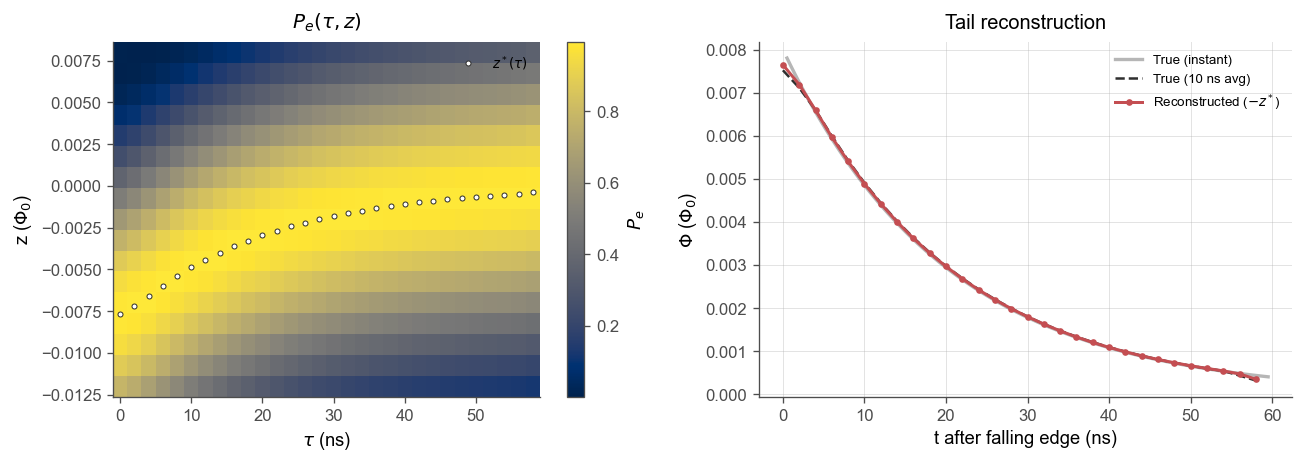

-z* vs 10-ns moving-avg tail RMSE = 0.000031 Phi0


In [8]:
from sqc.experiments.pi_pulse_comp import PiPulseCompensationExperiment
from sqc.reconstruction.pi_pulse_comp import PiPulseCompReconstruction

qubit = make_qubit(flux=0.25)
omega_bias = qubit.frequency
T_pi = 10.0

# 测试信号（与 A5 相同：平台 + 指数拖尾）
t_list = CONFIG.pulse.make_time(0, 100)
sig = np.zeros(len(t_list))
sig[(t_list >= 10) & (t_list <= 40)] = 0.008
sig[t_list > 40] = 0.008 * np.exp(-(t_list[t_list > 40] - 40) / 20)
test_flux = FluxSignal(type=8, t_list=t_list, signal=sig)

# 2D 扫描 (τ, z)：补偿 flux z 抵消拖尾相位，最优 z*(τ) 即 −Φ_tail
tau_list = CONFIG.pulse.make_time(0, 60)[::4]
z_list = np.linspace(-0.012, 0.008, 17)
result = PiPulseCompensationExperiment(
    qubit=qubit, flux_signal=test_flux, tau_list=tau_list, z_list=z_list,
    T_pi=T_pi, omega_bias=omega_bias, t_rabi=np.linspace(0, 10, 20),
    t_fall=40.0,
).run()

# 重建：Φ_tail = −z*
tail_flux = PiPulseCompReconstruction().reconstruct(result)
tail_avg = np.array([
    np.mean([float(test_flux.value_at(40.0 + tau + t))
             for t in np.linspace(-T_pi / 2, T_pi / 2, 21)])
    for tau in tau_list
])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
Tg, Zg = np.meshgrid(tau_list, z_list, indexing="ij")
im = axes[0].pcolormesh(Tg, Zg, result.data["p_e"], cmap=CMAP_SEQ, shading="auto")
axes[0].plot(tau_list, result.data["z_star"], "o", color="white", ms=3,
             markeredgecolor=C_REF, markeredgewidth=0.6, label=r"$z^*(\tau)$")
axes[0].set(xlabel=r"$\tau$ (ns)", ylabel=r"z ($\Phi_0$)", title=r"$P_e(\tau, z)$")
plt.colorbar(im, ax=axes[0], label="$P_e$"); axes[0].legend(fontsize=8)
axes[1].plot(t_list[t_list > 40] - 40, sig[t_list > 40], "-", color=C_REF, lw=2,
             alpha=0.35, label="True (instant)")
axes[1].plot(tau_list, tail_avg, "--", color=C_REF, lw=1.5, label=f"True ({T_pi:.0f} ns avg)")
axes[1].plot(tau_list, tail_flux.signal, "o-", color=C_REC, ms=4,
             label=r"Reconstructed ($-z^*$)")
axes[1].set(xlabel="t after falling edge (ns)", ylabel=r"$\Phi$ ($\Phi_0$)",
            title="Tail reconstruction")
axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()
print(f"-z* vs {T_pi:.0f}-ns moving-avg tail RMSE = "
      f"{np.sqrt(np.mean((tail_flux.signal - tail_avg) ** 2)):.6f} Phi0")

## A7. 高层 API 与参数扫描 — `SensingWorkflow`

`SensingWorkflow` 是单点科研入口，把「`FluxSignal` → `Experiment` → `Reconstruction`」
多类流水线收进统一的 `configure()` + `run()` + `sweep()` + `compare()` + `plot()`。
下面先跑一次瞬态传感，再用 `sweep()` 扫输入幅度与 Wiener 正则化 $\lambda$，观察重建随参
数的变化。

注意 `sweep()` 用点号路径（`"signal.amplitude"`），与 `configure()` 的扁平参数名不同。

Sliding measurement with 579 samples took 7.58 seconds


Sliding measurement with 579 samples took 8.26 seconds


Kernel computation took 0.94 seconds


C:\Users\21034\Desktop\Workspace\Sensing project\Sensing-Project\sqc\workflows\sensing.py:725: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\21034\anaconda3\envs\qutip-env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


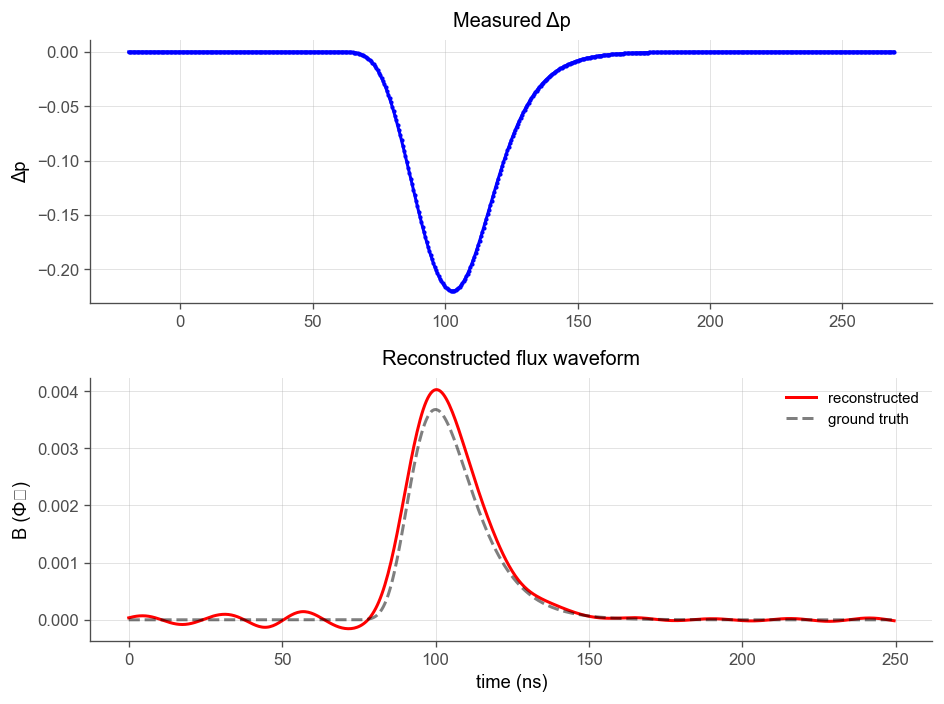

Sliding measurement with 579 samples took 8.92 seconds


Sliding measurement with 579 samples took 7.83 seconds


Kernel computation took 0.68 seconds


Sliding measurement with 579 samples took 6.85 seconds


Sliding measurement with 579 samples took 6.40 seconds


...

Sliding measurement with 579 samples took 6.13 seconds


Kernel computation took 0.65 seconds


Sliding measurement with 579 samples took 6.53 seconds


Sliding measurement with 579 samples took 5.82 seconds


Kernel computation took 0.66 seconds


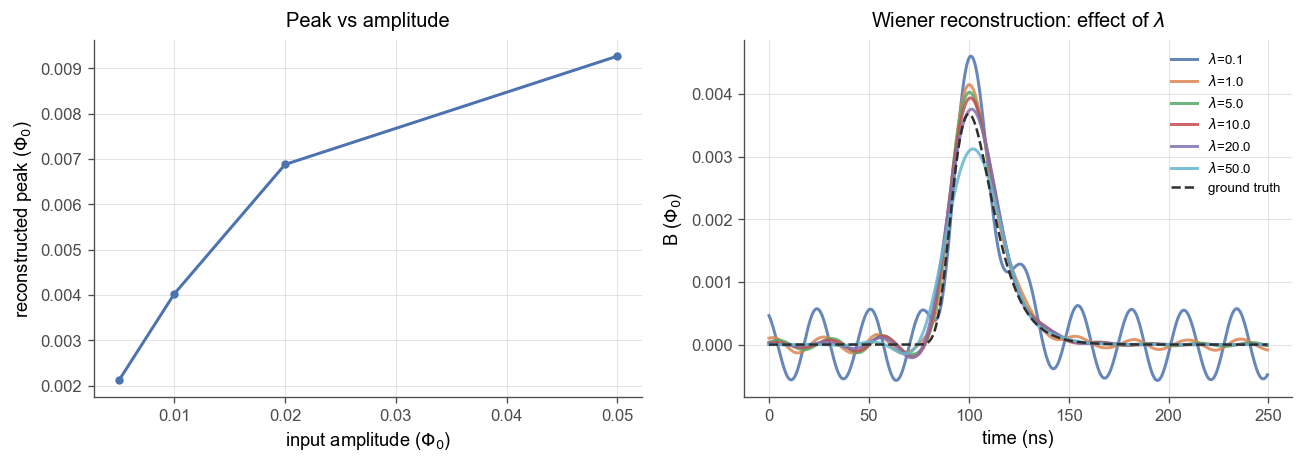

In [9]:
from sqc.workflows import SensingWorkflow

# 单次瞬态传感 + 一键出图
wf = SensingWorkflow()
wf.configure(protocol="transient", signal_type=4, reconstruction="wiener",
             t_rabi_duration=20, t_global_start=0, t_global_end=250,
             n_levels=2, lambda_reg=5.0, flux_bias=0.9553)
wf.run(measure=True, reconstruct=True)
wf.plot()

# sweep() 用点号路径参数名。左：扫输入幅度（重建峰值近似线性）；
# 右：扫 Wiener 正则化 λ（小 λ 尖锐但噪声大，大 λ 平滑但衰减）。
amplitudes = [0.005, 0.01, 0.02, 0.05]
sweep_amp = wf.sweep("signal.amplitude", amplitudes)

wf2 = SensingWorkflow()
wf2.configure(protocol="transient", signal_type=4, signal_amplitude=0.01,
              reconstruction="wiener", t_rabi_duration=20,
              t_global_start=0, t_global_end=250, n_levels=2, flux_bias=0.9553)
lambdas = [0.1, 1.0, 5.0, 10.0, 20.0, 50.0]
sweep_reg = wf2.sweep("reconstruction.lambda_reg", lambdas)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(amplitudes, sweep_amp.metrics["peak"], "o-", color=C_DATA)
ax1.set(xlabel=r"input amplitude ($\Phi_0$)",
        ylabel=r"reconstructed peak ($\Phi_0$)", title="Peak vs amplitude")
for i, wr in enumerate(sweep_reg.results):
    ax2.plot(wr.reconstructed_signal.t_list, wr.reconstructed_signal.signal,
             alpha=0.85, label=fr"$\lambda$={lambdas[i]:.1f}")
gt = sweep_reg.results[0].measurement.data.get("flux_samples")
t_gt = sweep_reg.results[0].measurement.axes.get("t_flux")
if gt is not None and t_gt is not None:
    ax2.plot(t_gt, gt, "--", color=C_REF, lw=1.5, label="ground truth")
ax2.set(xlabel="time (ns)", ylabel=r"B ($\Phi_0$)",
        title=r"Wiener reconstruction: effect of $\lambda$")
ax2.legend(fontsize=8)
fig.tight_layout(); plt.show()

# 第二部分 · 频率标定

围绕 `sqc.calibration.frequency` 与 `sqc.workflows.frequency_calibration`，本部分分两块：

- **B1 单点测频对比** —— 同一已知失谐下，标准 Ramsey（$\tau$ 扫 + FFT）与瞬态测频
  （$\tau{=}0$ 正交读出 + 核灵敏度）的精度、有效窗、代价三维对比。
- **B2 闭环频率标定** —— 用根查找把 $f_q(V)$ 调到目标：先看纯梯度闭环，再看
  **瞬态粗调 → Ramsey 精修**的混合工作流，最后对比 secant / bisection / gradient 收敛性。

统一约定：所有 qubit 在**甜点**（flux=0）构造，失谐由测量/闭环施加的 flux 偏置产生；
频率为角频率（rad·GHz），换算 MHz 用 $f_\text{MHz}=\omega/2\pi\times10^3$。

## B1. 单点测频对比 — 标准 Ramsey vs 瞬态测频

`FrequencyMeasurement` 提供两种单点测频：

- `method="ramsey"` —— $\tau$ 扫 + FFT 峰。稳健、有符号、全程适用；代价高。这里用
  **双扫**（`f_artificial=None`）：在 $\pm f_a$ 两个人工失谐下各扫一次，
  $\Delta=(f_n^2-f_p^2)/(4f_a)$。相比单扫（`f_artificial=0.1`，用 $\Delta=f_a-f_\text{meas}$
  从 0.1 GHz 做**大数相减**，残留 ~130 kHz 系统偏置），双扫让公共 FFT 偏置**一阶抵消**、
  失谐直接出，精度提到 **kHz 级**；代价是每点两扫（mesolve 翻倍）。
- `method="transient"` —— $\tau{=}0$ 正交 Ramsey 差分 + 控制核灵敏度
  $G_\text{freq}=\int k_1\,dt$，直接反演 $\Delta\omega$。极省（每次 $\sim2$ 次 mesolve），
  但依赖弱信号线性近似：**近根准、远根偏**。`order=3` 加三次牛顿修正在近根处更精确。

  三次修正解 $p_\text{diff}=G_\text{lin}\,\delta\omega+\tfrac{G_3}{6}\delta\omega^3$。当
  $G_\text{lin}$ 与 $G_3$ 反号时，$p_\text{diff}(\delta\omega)$ 在
  $|\delta\omega_\text{fold}|=\sqrt{-2G_\text{lin}/G_3}$ 处**折返**，越过后三次不可逆、
  Newton 会跳到反号的远根（大幅符号翻转误差）。`_solve_cubic_detuning` 内置**折点护栏**：
  一旦解越过折点即判为不可信，**自动回退 order-1 线性估计**——所以 order-3 在有效窗外不再
  过冲，而是优雅退化到与 order-1 一致。

在甜点 qubit 上施加一组已知 flux 偏置构造已知失谐 $\Delta_\text{true}$，三法各测，从
**精度、有效窗、代价**三个维度对比。有效窗（误差 <0.5 MHz 的最大 $|\Delta|$）由数据现算。

In [10]:
from sqc.calibration.frequency import FrequencyMeasurement, _g3_cache

TWO_PI = 2 * np.pi
to_MHz = lambda w: w / TWO_PI * 1e3
to_kHz = lambda w: w / TWO_PI * 1e6

# 甜点 qubit（复用于所有单点测量）；失谐由 measure(flux) 施加的偏置产生。
q0 = make_qubit(flux=0.0)
omega_d = q0.frequency

# B 部分统一的精简时间轴（mesolve 密集；脉后失谐不改 p_e，故 t_global 可短）。
TR_B = CONFIG.pulse.make_time(0, 20)
TAU_B = CONFIG.pulse.make_time(0, 100)
TG_RAMSEY = CONFIG.pulse.t_global.copy()      # Ramsey 第二个 π/2 在 t≈τ，需长轴
TG_TRANS = CONFIG.pulse.make_time(0, 40)      # 瞬态 τ=0，短轴足够

flux_scan = np.array([0.008, 0.015, 0.022, 0.030, 0.038, 0.045])
d_true, d_ram, d_t1, d_t3 = [], [], [], []
for h in flux_scan:
    w_true = make_qubit(flux=h).frequency           # 该偏置下的真实 f_q
    d_true.append(to_MHz(w_true - omega_d))
    # 双扫（f_artificial=None）：±f_a 两扫，Δ=(f_n²−f_p²)/(4f_a)，公共 FFT 偏置
    # 一阶抵消、失谐直接出，无大数相减 → kHz 精度（对比单扫 f_artificial=0.1 的
    # ~130 kHz 系统偏置）。代价是每点 2 次扫（mesolve 翻倍）。
    f_r = FrequencyMeasurement(qubit=q0, method="ramsey", tau_list=TAU_B,
                               t_rabi=TR_B, t_global=TG_RAMSEY,
                               f_artificial=None).measure(h)
    d_ram.append(to_MHz(f_r - omega_d))
    f_t1 = FrequencyMeasurement(qubit=q0, method="transient", order=1,
                                t_rabi=TR_B, t_global=TG_TRANS).measure(h)
    d_t1.append(to_MHz(f_t1 - omega_d))
    _g3_cache.clear()
    f_t3 = FrequencyMeasurement(qubit=q0, method="transient", order=3,
                                g3_source="fit", t_rabi=TR_B,
                                t_global=TG_TRANS).measure(h)
    d_t3.append(to_MHz(f_t3 - omega_d))

d_true = np.array(d_true); d_ram = np.array(d_ram)
d_t1 = np.array(d_t1); d_t3 = np.array(d_t3)
print("Δtrue (MHz)     :", np.round(d_true, 2))
print("ramsey err (kHz):", np.round((d_ram - d_true) * 1e3, 0))   # 双扫 → kHz 级
print("trans1 err (MHz):", np.round(d_t1 - d_true, 2))
print("trans3 err (MHz):", np.round(d_t3 - d_true, 2))

Kernel computation (omega, math) took 0.23 seconds


Kernel computation (omega, math) took 0.23 seconds


Kernel computation (omega, math) took 0.23 seconds


Kernel computation (omega, math) took 0.22 seconds


G3 Taylor calibration (adaptive): 0.3s, G1=-12.5315, G3=8319.9, G3/G1=-663.9 ns^2


...

Kernel computation (omega, math) took 0.28 seconds


Kernel computation (omega, math) took 0.27 seconds


Kernel computation (omega, math) took 0.26 seconds


Kernel computation (omega, math) took 0.23 seconds


G3 Taylor calibration (adaptive): 0.3s, G1=-12.5315, G3=8319.9, G3/G1=-663.9 ns^2
Δtrue (MHz)     : [ -0.63  -2.22  -4.78  -8.89 -14.26 -20.  ]
ramsey err (kHz): [ -2.  -2. -42. -36.  41.  22.]
trans1 err (MHz): [-1.00e-02  2.00e-02  4.10e-01  2.63e+00  9.08e+00  1.86e+01]
trans3 err (MHz): [-0.   -0.   -0.02  2.7   8.14 18.6 ]


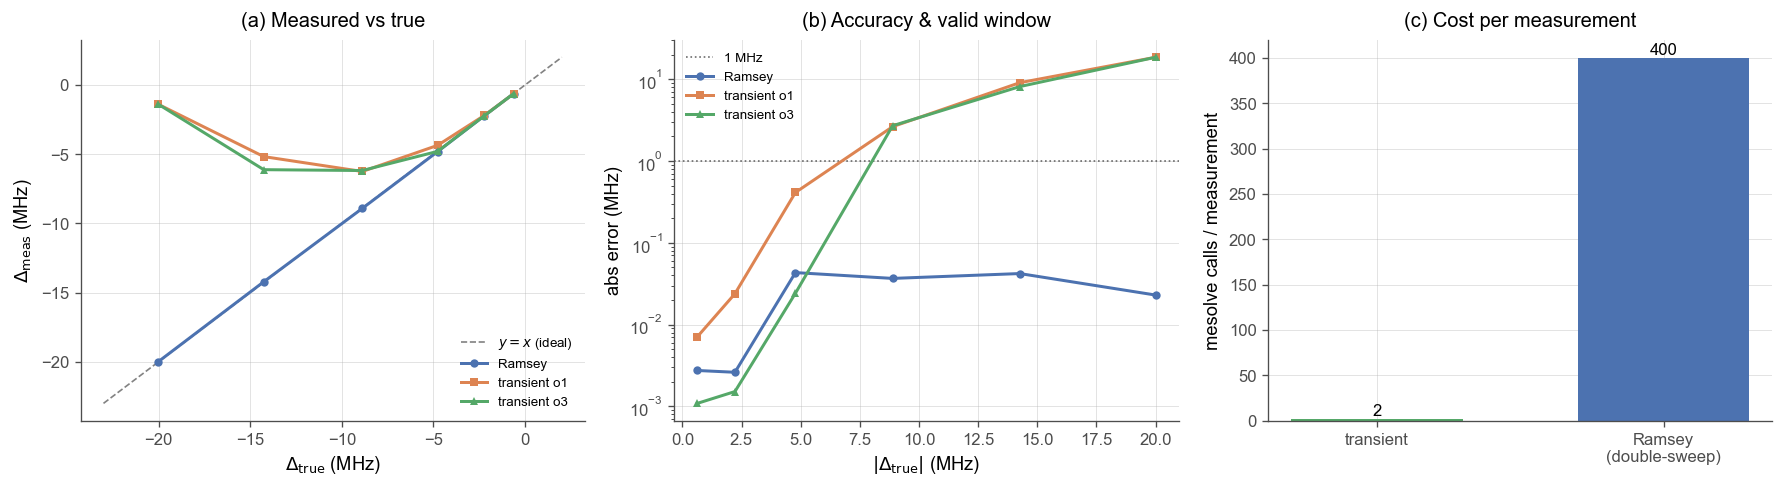

Ramsey（双扫）：全程误差 <42 kHz，稳健有符号；代价 400×/测量。
瞬态 order-1：有效窗 |Δ|≲5 MHz（<0.5 MHz），超出后线性偏低。
瞬态 order-3：有效窗 |Δ|≲5 MHz 内近乎精确（<0.02 MHz）；越折点后**折点护栏**自动回退 order-1，不再过冲（o3−o1 最大误差差 +0.07 MHz）。
→ 瞬态单次代价约 200× 更低，宜用于近根快速逼近；下方 B1b 展示如何把瞬态精度也提到 kHz。


In [11]:
# 三维对比：(a) 测量值 vs 真值  (b) 绝对误差(对数)  (c) 每次测量代价
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# (a) 测量值 vs 真值
lim = [d_true.min() * 1.15, 2]
axes[0].plot(lim, lim, "--", color=C_REF, lw=1, alpha=0.6, label="$y=x$ (ideal)")
axes[0].plot(d_true, d_ram, "o-", color=PALETTE[0], label="Ramsey")
axes[0].plot(d_true, d_t1, "s-", color=PALETTE[1], label="transient o1")
axes[0].plot(d_true, d_t3, "^-", color=PALETTE[2], label="transient o3")
axes[0].set(xlabel=r"$\Delta_\mathrm{true}$ (MHz)", ylabel=r"$\Delta_\mathrm{meas}$ (MHz)",
            title="(a) Measured vs true")
axes[0].legend(fontsize=8)

# (b) 绝对误差（对数 y），标出 1 MHz 参考线
axes[1].axhline(1.0, color=C_REF, ls=":", lw=1, alpha=0.7, label="1 MHz")
axes[1].semilogy(np.abs(d_true), np.abs(d_ram - d_true) + 1e-3, "o-", color=PALETTE[0], label="Ramsey")
axes[1].semilogy(np.abs(d_true), np.abs(d_t1 - d_true) + 1e-3, "s-", color=PALETTE[1], label="transient o1")
axes[1].semilogy(np.abs(d_true), np.abs(d_t3 - d_true) + 1e-3, "^-", color=PALETTE[2], label="transient o3")
axes[1].set(xlabel=r"$|\Delta_\mathrm{true}|$ (MHz)", ylabel="abs error (MHz)",
            title="(b) Accuracy & valid window")
axes[1].legend(fontsize=8)

# (c) 每次测量的 mesolve 代价（瞬态 ~2；Ramsey 双扫 ~2×len(tau)）
cost = {"transient": 2, "Ramsey\n(double-sweep)": 2 * len(TAU_B)}
axes[2].bar(cost.keys(), cost.values(), color=[PALETTE[2], PALETTE[0]], width=0.6)
axes[2].set(ylabel="mesolve calls / measurement", title="(c) Cost per measurement")
for i, v in enumerate(cost.values()):
    axes[2].text(i, v, str(v), ha="center", va="bottom", fontsize=10)
fig.tight_layout(); plt.show()

# 数据驱动的结论：有效窗 = 误差 <0.5 MHz 的最大 |Δ|（避免硬编码与实际脱节）
def valid_window(err):
    ok = np.abs(err) < 0.5
    return np.abs(d_true[ok]).max() if ok.any() else 0.0
w1, w3 = valid_window(d_t1 - d_true), valid_window(d_t3 - d_true)
ram_err_khz = np.max(np.abs(d_ram - d_true)) * 1e3   # 双扫全程最大误差 → kHz
# 折点护栏生效：o3 越窗后回退 o1，误差不应显著大于 o1（无符号翻转过冲）
o3_overshoot = float(np.max(np.abs(d_t3 - d_true) - np.abs(d_t1 - d_true)))
print(f"Ramsey（双扫）：全程误差 <{ram_err_khz:.0f} kHz，稳健有符号；代价 {2*len(TAU_B)}×/测量。")
print(f"瞬态 order-1：有效窗 |Δ|≲{w1:.0f} MHz（<0.5 MHz），超出后线性偏低。")
print(f"瞬态 order-3：有效窗 |Δ|≲{w3:.0f} MHz 内近乎精确（<0.02 MHz）；越折点后**折点护栏**"
      f"自动回退 order-1，不再过冲（o3−o1 最大误差差 {o3_overshoot:+.2f} MHz）。")
print(f"→ 瞬态单次代价约 {(2*len(TAU_B))//2}× 更低，宜用于近根快速逼近；下方 B1b 展示如何把瞬态精度也提到 kHz。")

### B1b 提升瞬态精度 — 驱动重心 bootstrapping

瞬态测频的误差**来自弱信号线性/三次近似**，而近似只在残余失谐 $\Delta=f_q-\omega_d\to0$
时才精确。所以提精度的核心杠杆是**把驱动频率 $\omega_d$ 移到根附近**：

$$\hat f^{(k+1)} = \texttt{transient\_measure}(\omega_d=\hat f^{(k)}),\qquad \hat f^{(0)}=\omega_\text{sweet}$$

每次把驱动重心设到上一次估计 $\hat f^{(k)}$，残余失谐逐次缩小，线性近似逐次变精确——
这本质是对测量本身做**不动点/牛顿迭代**。order-1 是稳定的**压缩映射**（线性总是同号低估，
重心化单调缩小 $|\Delta|$），故收敛可靠；order-3 在**折点外**重心化会失稳发散，因此
bootstrapping 用 **order-1**（order-3 留给单发近根场景）。

下面对三个失谐点（含 B1 最难的 $\Delta\approx-20$ MHz）各迭代 3 次，看误差从 MHz 收到 kHz。
代价：每多一次迭代多 ~2 次 mesolve——仍远低于一次 Ramsey 双扫（$2\times$len(tau)）。

> 这也正是 B2 闭环标定“瞬态粗调”能奏效的机理：闭环每步调偏置 $V$ 同样在缩小残余失谐，
> 把瞬态推进它自己的精确区。

Kernel computation (omega, math) took 0.22 seconds


Kernel computation (omega, math) took 0.23 seconds


Kernel computation (omega, math) took 0.24 seconds


Kernel computation (omega, math) took 0.24 seconds


Kernel computation (omega, math) took 0.23 seconds


...

Kernel computation (omega, math) took 0.23 seconds


Kernel computation (omega, math) took 0.23 seconds


Kernel computation (omega, math) took 0.23 seconds


Kernel computation (omega, math) took 0.24 seconds


Kernel computation (omega, math) took 0.23 seconds


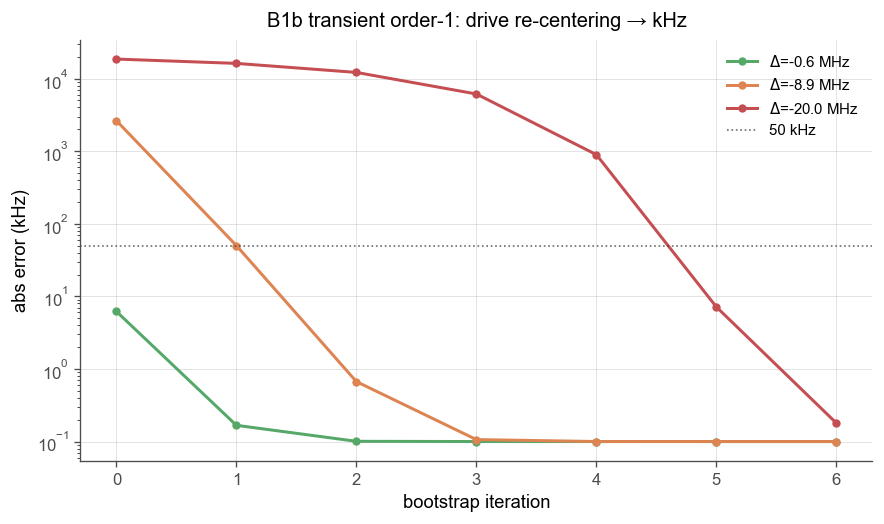

Δtrue(MHz)   iter0 err(kHz)   final err(kHz)   iters→<50kHz
    -0.63             +6             +0       0
    -8.89          +2633             +0       2
   -20.00         +18595             +0       5
→ 驱动重心 bootstrapping 把单发瞬态的 MHz 误差逐次收到 kHz；每次仅多 ~2 mesolve。收敛步数随初始失谐增大：近根 1 步、中等 2–3 步、Δ≈-20 MHz（4× 有效窗）需 ~6 步（窗外慢爬、入窗后快收）。order-1 为压缩映射故稳收；order-3 折点外发散，故用 order-1。


In [12]:
from sqc.calibration.frequency import _measure_frequency_transient

# 驱动重心 bootstrapping：把 omega_d 迭代设到上一次估计，缩小残余失谐 → order-1
# 线性近似逐次变精确。公共 measure() 把 omega_d 锁在甜点，故直接调内层函数传 omega_d。
def transient_bootstrap(flux, n_iter=6, order=1):
    wd = omega_d                       # 初始驱动 = 甜点频率
    est = []
    for _ in range(n_iter + 1):
        _g3_cache.clear()
        f_hat = _measure_frequency_transient(
            q0, wd, TR_B, TG_TRANS, flux=flux, order=order, g3_source="fit")
        est.append(f_hat)
        wd = f_hat                      # 重心化：下一次驱动 = 本次估计
    return np.array(est)

boot_fluxes = [0.008, 0.030, 0.045]    # Δ ≈ -0.6, -8.9, -20 MHz
THRESH = 50.0                          # kHz 收敛判据
fig, ax = plt.subplots(figsize=(7.5, 4.5))
rows = []
for h, col in zip(boot_fluxes, (PALETTE[2], PALETTE[1], PALETTE[3])):
    w_true = make_qubit(flux=h).frequency
    est = transient_bootstrap(h, n_iter=6, order=1)
    err = np.abs(to_kHz(est - w_true))                # kHz
    ax.semilogy(range(len(est)), err + 1e-1, "o-", color=col,
                label=fr"$\Delta$={to_MHz(w_true-omega_d):+.1f} MHz")
    hit = np.argmax(err < THRESH) if (err < THRESH).any() else -1  # 首次达标迭代
    rows.append((to_MHz(w_true - omega_d), err[0], err[-1], hit))
ax.axhline(THRESH, color=C_REF, ls=":", lw=1, alpha=0.7, label=f"{THRESH:.0f} kHz")
ax.set(xlabel="bootstrap iteration", ylabel="abs error (kHz)",
       title="B1b transient order-1: drive re-centering → kHz")
ax.legend(fontsize=9); fig.tight_layout(); plt.show()

print("Δtrue(MHz)   iter0 err(kHz)   final err(kHz)   iters→<50kHz")
for d, e0, ef, hit in rows:
    print(f"  {d:+7.2f}      {e0:+9.0f}      {ef:+9.0f}       {hit if hit>=0 else '>6'}")
print("→ 驱动重心 bootstrapping 把单发瞬态的 MHz 误差逐次收到 kHz；每次仅多 ~2 mesolve。"
      "收敛步数随初始失谐增大：近根 1 步、中等 2–3 步、Δ≈-20 MHz（4× 有效窗）需 ~6 步"
      "（窗外慢爬、入窗后快收）。order-1 为压缩映射故稳收；order-3 折点外发散，故用 order-1。")

## B2. 闭环频率标定 — `SinglePointFrequencyCalibration` / `FrequencyCalibrationWorkflow`

把 qubit 频率 $f_q(V)$ 调到目标 $f_\text{target}$，即对残差 $r(V)=f_q(V)-f_\text{target}$
做根查找。`SinglePointFrequencyCalibration` 提供三种 `step_method`（secant / bisection /
gradient），每步测量委托内部 `FrequencyMeasurement`。

三小节递进：**B2.1** 纯梯度闭环轨迹 → **B2.2** 瞬态粗调 + Ramsey 精修的混合工作流 →
**B2.3** 三种更新算法的收敛性对比。

### B2.1 纯梯度闭环（Ramsey 测量）

`step_method="gradient"` 是阻尼割线/数值牛顿：步长 $\text{damping}\cdot e\cdot(dV/de)$，
带 clamp 和 best-point 跟踪，**只需 `V_seed`、无需预括号**。首步用固定探针步。下面从
甜点附近 seed 出发，把频率调到目标（$\Delta\approx-6$ MHz 对应的偏置）。

target Δ = -5.69 MHz  (root ≈ flux 0.024)


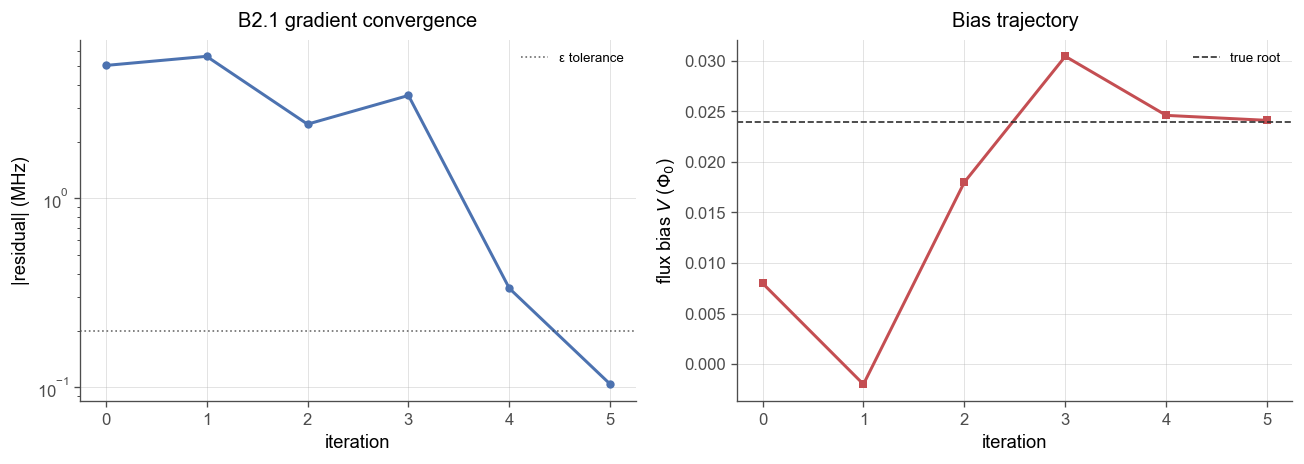

converged=True, 5 iters, V_opt=0.0241, residual=-0.1040 MHz


In [13]:
from sqc.calibration.frequency import SinglePointFrequencyCalibration

# 目标：flux=0.024 处的 f_q（甜点下方约 -6 MHz）
eps_g = TWO_PI * 2e-4
f_target = make_qubit(flux=0.024).frequency
print(f"target Δ = {to_MHz(f_target - omega_d):.2f} MHz  (root ≈ flux 0.024)")

cal_g = SinglePointFrequencyCalibration(
    qubit=q0, f_target=f_target, V_seed=0.008,
    measure_method="ramsey", step_method="gradient",
    epsilon_f=eps_g, max_iter=8,
    tau_list=TAU_B, t_rabi=TR_B, t_global=TG_RAMSEY,
).calibrate()

hist = cal_g.fit_params["history"]
it = [h["iter"] for h in hist]
res = [abs(to_MHz(h["residual"])) for h in hist]
Vs = [h["V"] for h in hist]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.semilogy(it, res, "o-", color=C_DATA)
ax1.axhline(to_MHz(eps_g), color=C_REF, ls=":", lw=1, alpha=0.7, label="ε tolerance")
ax1.set(xlabel="iteration", ylabel="|residual| (MHz)", title="B2.1 gradient convergence")
ax1.legend(fontsize=8)
ax2.plot(it, Vs, "s-", color=C_REC)
ax2.axhline(0.024, color=C_REF, ls="--", lw=1, label="true root")
ax2.set(xlabel="iteration", ylabel=r"flux bias $V$ ($\Phi_0$)", title="Bias trajectory")
ax2.legend(fontsize=8)
fig.tight_layout(); plt.show()

print(f"converged={cal_g.fit_params['converged']}, {cal_g.fit_params['n_iter']} iters, "
      f"V_opt={cal_g.fit_params['V_opt']:.4f}, residual={to_MHz(cal_g.fit_params['residual']):.4f} MHz")

### B2.2 混合工作流：瞬态粗调 → Ramsey 精修（`stages` 流水线的默认预设）

单策略闭环类的 `measure_method` 在构造时固定，**不能环内切换**。因此把「前期瞬态快速逼近
→ 末期 Ramsey 精修」编排为一等公民的 `FrequencyCalibrationWorkflow`（`sqc.workflows`）：

- **Phase 1（粗调）**：`transient + gradient`，松容差 `switch_residual`。每步仅 ~2 次
  mesolve，用 B1 确立的有效窗内快速把残差拉到几 MHz。
- **Phase 2（精修）**：残差越过阈值后切到 `ramsey`，以 Phase 1 的 `V_opt` 为 seed 收到紧容差。

这个 2 段 hybrid 只是**默认预设**——不传 `stages` 时由扁平参数自动构建。工作流本质是一条
**任意 N 段的 `CalibrationStage` 流水线**：每段独立选测量法/步进器/容差/测量时间轴，后段
以前段 `V_opt` 为 seed。下面先看默认 hybrid，再看自定义 3 段（B2.2b）。

`run()` 合并各段 history（带 `phase` 标记与累计 mesolve 代价）。下图叠加收敛曲线与代价。

Kernel computation (omega, math) took 0.32 seconds


Kernel computation (omega, math) took 0.25 seconds


G3 Taylor calibration (adaptive): 1.9s, G1=-12.6528, G3=8527.2, G3/G1=-673.9 ns^2


Kernel computation (omega, math) took 0.22 seconds


Kernel computation (omega, math) took 0.23 seconds


Kernel computation (omega, math) took 0.23 seconds


Kernel computation (omega, math) took 0.22 seconds


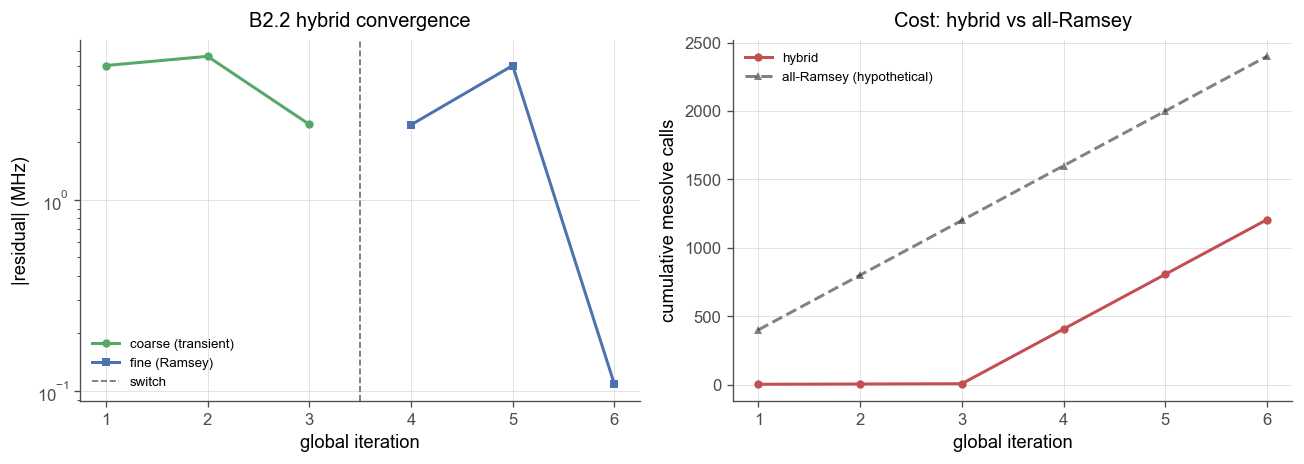

switch@iter 3: 3 coarse + 3 fine; residual=0.1082 MHz, converged=True
总代价 1206 vs 全程 Ramsey 2400  →  约 2.0× 更省


In [14]:
from sqc.workflows import FrequencyCalibrationWorkflow

wf_hybrid = FrequencyCalibrationWorkflow(
    qubit=q0, f_target=f_target, V_seed=0.008,
    switch_residual=TWO_PI * 3e-3,      # 切到 Ramsey 的残差阈（3 MHz）
    epsilon_f=TWO_PI * 5e-4,            # 精修最终容差
    coarse_max_iter=6, fine_max_iter=5, transient_order=3,
    tau_list=TAU_B, t_rabi=TR_B, t_global=TG_RAMSEY,
)
res_h = wf_hybrid.run()
H = res_h["history"]
gi = [h["global_iter"] for h in H]
r_mhz = [abs(to_MHz(h["residual"])) for h in H]
cost_cum = [h["cost"] for h in H]
sw = res_h["switch_iter"]
coarse = [i for i, h in enumerate(H) if h["phase"] == "coarse"]
fine = [i for i, h in enumerate(H) if h["phase"] == "fine"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
# 收敛曲线：粗调/精修分色，标注切换点
ax1.semilogy([gi[i] for i in coarse], [r_mhz[i] for i in coarse], "o-",
             color=PALETTE[2], label="coarse (transient)")
ax1.semilogy([gi[i] for i in fine], [r_mhz[i] for i in fine], "s-",
             color=PALETTE[0], label="fine (Ramsey)")
ax1.axvline(sw + 0.5, color=C_REF, ls="--", lw=1, alpha=0.7, label="switch")
ax1.set(xlabel="global iteration", ylabel="|residual| (MHz)",
        title="B2.2 hybrid convergence")
ax1.legend(fontsize=8)
# 累计代价：混合 vs 全程 Ramsey
ramsey_only = np.arange(1, len(H) + 1) * res_h["metrics"]["cost_ramsey_per_meas"]
ax2.plot(gi, cost_cum, "o-", color=PALETTE[3], label="hybrid")
ax2.plot(gi, ramsey_only, "^--", color=C_REF, alpha=0.6, label="all-Ramsey (hypothetical)")
ax2.set(xlabel="global iteration", ylabel="cumulative mesolve calls",
        title="Cost: hybrid vs all-Ramsey")
ax2.legend(fontsize=8)
fig.tight_layout(); plt.show()

speedup = ramsey_only[-1] / cost_cum[-1]
print(f"switch@iter {sw}: {res_h['metrics']['coarse_iter']} coarse + "
      f"{res_h['metrics']['fine_iter']} fine; residual={to_MHz(res_h['residual']):.4f} MHz, "
      f"converged={res_h['converged']}")
print(f"总代价 {res_h['metrics']['total_cost']} vs 全程 Ramsey {int(ramsey_only[-1])}"
      f"  →  约 {speedup:.1f}× 更省")

### B2.2b 自定义流水线 — 任意 N 段 + 自适应切换 `advance_when`

同一个 `FrequencyCalibrationWorkflow`，传入显式 `stages=[...]` 即可编排任意流程。这里演示
**3 段**，每段独立配置，展示默认 hybrid 无法表达的三件事：

1. **粗 `transient` order-1，短 `t_global`** —— 远根时线性核足够，用短时间轴把单步代价压到最低。
2. **中 `transient` order-3** —— 升阶提精度，但 order-1 粗调把 V 落在 order-3 有效窗边缘
   （B1），从这里 order-3 的梯度估计**震荡、停滞**在几 MHz 不再改善。挂 `advance_when`
   做**停滞检测**：最优残差连续若干步不再刷新就自适应交棒，省下空转的迭代——这正是
   残差阈值表达不了、需要运行时信号的场景。
3. **精 `ramsey`，长 `t_global`** —— 收尾要精度与稳健，用长时间轴收到 <0.5 MHz。

`advance_when` 仅对 gradient 段有效（映射到内层 `stop_predicate`）。下面 `stopped_by` 会显示
中段确实以 `'predicate'` 结束，早于它的 `epsilon_f`/`max_iter`。

Kernel computation (omega, math) took 0.22 seconds


Kernel computation (omega, math) took 0.24 seconds


Kernel computation (omega, math) took 0.24 seconds


Kernel computation (omega, math) took 0.23 seconds


Kernel computation (omega, math) took 0.22 seconds


...

Kernel computation (omega, math) took 0.22 seconds


Kernel computation (omega, math) took 0.23 seconds


Kernel computation (omega, math) took 0.24 seconds


Kernel computation (omega, math) took 0.23 seconds


Kernel computation (omega, math) took 0.23 seconds


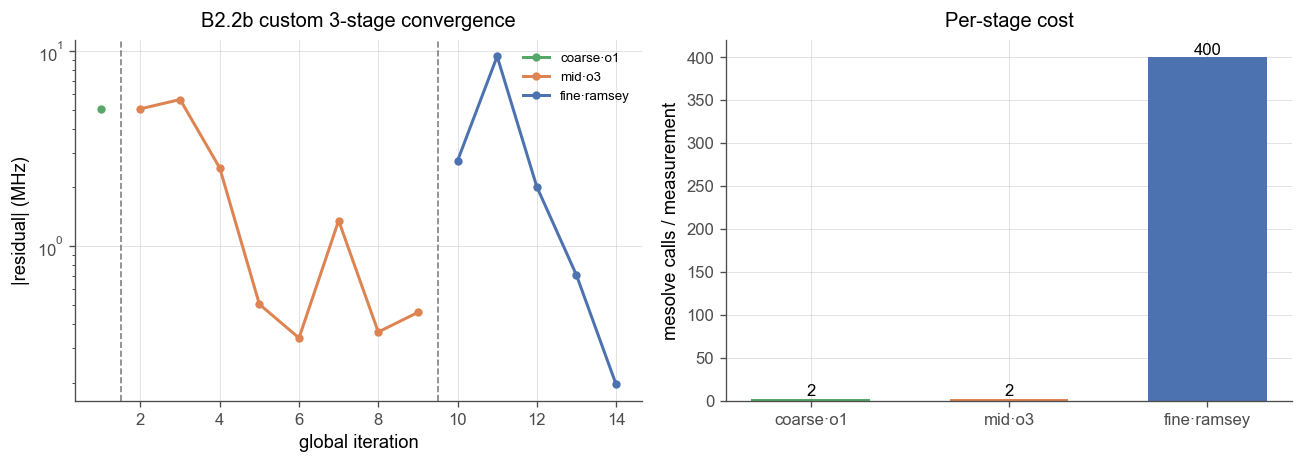

stages=['coarse·o1', 'mid·o3', 'fine·ramsey']
每段迭代=[1, 8, 5], 边界=[1, 9, 14], 每段停止原因=['tolerance', 'predicate', 'tolerance']
每段单步代价=[2, 2, 400] mesolve/measurement, 总代价=2018
V_final=0.0243, residual=-0.1958 MHz, converged=True
→ 中段 stopped_by='predicate'：order-3 在有效窗边缘停滞，advance_when 检测到最优残差不再刷新即交棒（早于 max_iter=12），省下空转迭代；末段 Ramsey 收到 <0.5 MHz。


In [15]:
from sqc.workflows import CalibrationStage

# 停滞检测：最优残差连续 3 步不再刷新（改善 < 1e-4）就判定该测量法已榨干，交棒下一段。
_best = {"v": np.inf, "since": 0}
def stalled(s):
    if s["abs_residual"] < _best["v"] - 1e-4:
        _best["v"] = s["abs_residual"]; _best["since"] = 0
    else:
        _best["since"] += 1
    return _best["since"] >= 3

# 粗/中段用短瞬态轴 TG_TRANS（τ=0，短轴足够），精段用长轴 TG_RAMSEY
stages = [
    CalibrationStage(name="coarse·o1", measure_method="transient",
                     step_method="gradient", order=1,
                     epsilon_f=TWO_PI * 6e-3, max_iter=5, t_global=TG_TRANS),
    CalibrationStage(name="mid·o3", measure_method="transient",
                     step_method="gradient", order=3,
                     epsilon_f=TWO_PI * 1e-5, max_iter=12, t_global=TG_TRANS,
                     advance_when=stalled),   # order-3 在有效窗边缘停滞 → 自适应交棒
    CalibrationStage(name="fine·ramsey", measure_method="ramsey",
                     step_method="gradient",
                     epsilon_f=TWO_PI * 5e-4, max_iter=6,
                     tau_list=TAU_B, t_global=TG_RAMSEY),
]
wf_custom = FrequencyCalibrationWorkflow(
    qubit=q0, f_target=f_target, V_seed=0.008, stages=stages, t_rabi=TR_B,
)
res_c = wf_custom.run()
Hc = res_c["history"]
names = res_c["metrics"]["stage_names"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
# (a) 分段收敛，每段一色，边界竖线
seg_colors = {names[0]: PALETTE[2], names[1]: PALETTE[1], names[2]: PALETTE[0]}
for nm in names:
    pts = [(h["global_iter"], abs(to_MHz(h["residual"])) + 1e-4) for h in Hc if h["phase"] == nm]
    xs, ys = zip(*pts)
    ax1.semilogy(xs, ys, "o-", color=seg_colors[nm], label=nm)
for b in res_c["stage_boundaries"][:-1]:
    ax1.axvline(b + 0.5, color=C_REF, ls="--", lw=1, alpha=0.6)
ax1.set(xlabel="global iteration", ylabel="|residual| (MHz)",
        title="B2.2b custom 3-stage convergence")
ax1.legend(fontsize=8)
# (b) 每段单步代价（mesolve/measurement），凸显短轴粗调之省
ax2.bar(names, res_c["metrics"]["stage_costs"],
        color=[seg_colors[n] for n in names], width=0.6)
ax2.set(ylabel="mesolve calls / measurement", title="Per-stage cost")
for i, v in enumerate(res_c["metrics"]["stage_costs"]):
    ax2.text(i, v, str(v), ha="center", va="bottom", fontsize=10)
fig.tight_layout(); plt.show()

stopped = [t.fit_params.get("stopped_by") for t in res_c["stages"]]
print(f"stages={names}")
print(f"每段迭代={res_c['metrics']['stage_iters']}, 边界={res_c['stage_boundaries']}, "
      f"每段停止原因={stopped}")
print(f"每段单步代价={res_c['metrics']['stage_costs']} mesolve/measurement, "
      f"总代价={res_c['metrics']['total_cost']}")
print(f"V_final={res_c['V_final']:.4f}, residual={to_MHz(res_c['residual']):+.4f} MHz, "
      f"converged={res_c['converged']}")
print(f"→ 中段 stopped_by={stopped[1]!r}：order-3 在有效窗边缘停滞，advance_when 检测到最优"
      f"残差不再刷新即交棒（早于 max_iter=12），省下空转迭代；末段 Ramsey 收到 <0.5 MHz。")

### B2.2c 驱动频率跟随状态机 — acquire → track → lock（远目标 −20 MHz）

前面各段把驱动 $f_d$ **钉在甜点**测失谐。目标离甜点近时没问题;一旦远(这里 −20 MHz),瞬态鉴频器早已越出线性窗 $\Delta_\mathrm{lin}$,读数**有偏但仍报"收敛"**——闭环收到**错误的磁通**。修法是让驱动**跟随** qubit(观测器环),而误差始终相对**固定绝对目标**$e_k=\hat f_{q,k}-f_\mathrm{target}$ 计算(执行器环)。三段状态机:

- **acquire**(Ramsey,`drive="sweet"`):宽范围鲁棒定位,把 $f_q$ 拉进线性窗;
- **track**(瞬态 order-3,`drive="track"`):驱动按 $f_{d,k+1}=\hat f_{q,k}+\hat s_k\Delta V$ 预测下一点,让 $|\delta|$ 留在窗内;`omega_d_seed` 从 acquire 估计接棒,首轮不回落甜点;
- **lock**(瞬态,`drive="target"`,`converge_streak=3`):驱动钉目标,测得失谐即误差,连续达标 3 次才判收敛。

对照组:纯单段瞬态 + 甜点驱动(无跟随),看它在远目标下**停在错误磁通**。


far target Δ = -20.0 MHz  (root ≈ flux 0.045)


Kernel computation (omega, math) took 0.22 seconds


Kernel computation (omega, math) took 0.22 seconds


Kernel computation (omega, math) took 0.22 seconds


Kernel computation (omega, math) took 0.22 seconds


...

Kernel computation (omega, math) took 0.25 seconds


Kernel computation (omega, math) took 0.25 seconds


Kernel computation (omega, math) took 0.24 seconds


Kernel computation (omega, math) took 0.23 seconds


Kernel computation (omega, math) took 0.30 seconds


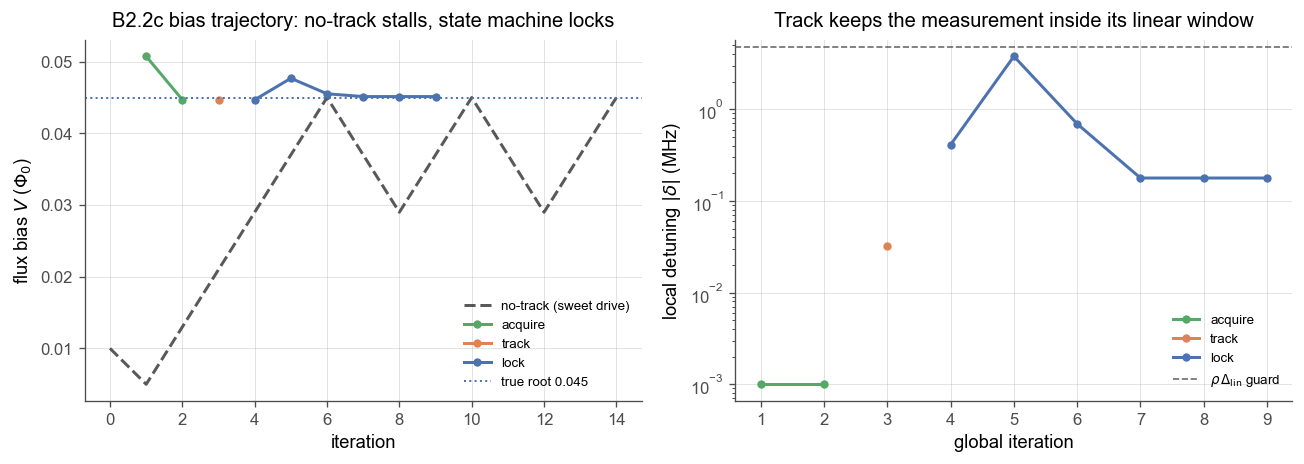

no-track  : V_opt=0.0370 (root 0.045), TRUE residual=+6484 kHz, converged=False → 停在错误磁通，甜点参考的读数有偏却仍报收敛
state-mc  : stages=['acquire', 'track', 'lock'], iters=[2, 1, 6], V_final=0.0451, TRUE residual=-119.6 kHz, converged=True
→ 驱动跟随把 |δ| 压在 8 MHz 窗内，误差始终相对固定绝对目标，状态机收到真根、精度 kHz 级；对照组差 6.5 MHz。


In [16]:
# --- 本节自包含：重建所需局部量（可在 setup/A0 后直接运行，不必先跑 B1/B2.1）---
from sqc.config import CONFIG
TWO_PI = 2 * np.pi
to_MHz = lambda w: w / TWO_PI * 1e3
to_kHz = lambda w: w / TWO_PI * 1e6
q0 = make_qubit(flux=0.0); omega_d = q0.frequency
TR_B = CONFIG.pulse.make_time(0, 20)
TAU_B = CONFIG.pulse.make_time(0, 100)
TG_TRANS = CONFIG.pulse.make_time(0, 40)
TG_RAMSEY = CONFIG.pulse.t_global.copy()

from sqc.calibration.frequency import SinglePointFrequencyCalibration
from sqc.workflows.frequency_calibration import FrequencyCalibrationWorkflow, CalibrationStage

# 远目标：flux=0.045 处的 f_q（甜点下方约 -20 MHz），单段瞬态的线性窗装不下
f_far = make_qubit(flux=0.045).frequency
print(f"far target Δ = {to_MHz(f_far - omega_d):.1f} MHz  (root ≈ flux 0.045)")

# --- 对照组：纯单段瞬态 + 甜点驱动（drive="sweet"，无跟随）---
base = SinglePointFrequencyCalibration(
    qubit=q0, f_target=f_far, V_seed=0.010,
    measure_method="transient", step_method="gradient", order=3,
    epsilon_f=TWO_PI * 3e-4, max_iter=14, drive_policy="sweet",
    sensitivity_source="model", t_rabi=TR_B, t_global=TG_TRANS,
    max_bias_step=0.008, first_bias_step=0.005,
).calibrate().fit_params
Hb = base["history"]
V_base_true = to_kHz(make_qubit(flux=base["V_opt"]).frequency - f_far)

# --- 状态机：acquire(Ramsey) → track(瞬态,跟随) → lock(瞬态,钉目标) ---
sm_stages = [
    CalibrationStage(name="acquire", measure_method="ramsey", step_method="secant",
                     V_a=0.0, V_b=0.08, epsilon_f=TWO_PI * 4e-3, max_iter=6,
                     tau_list=TAU_B, t_global=TG_RAMSEY),
    CalibrationStage(name="track", measure_method="transient", step_method="gradient",
                     order=3, drive_policy="track", sensitivity_source="model",
                     epsilon_f=TWO_PI * 4e-4, max_iter=8, t_global=TG_TRANS,
                     linear_range=TWO_PI * 8e-3, rho=0.6,
                     max_bias_step=0.01, first_bias_step=0.003),
    CalibrationStage(name="lock", measure_method="transient", step_method="gradient",
                     order=3, drive_policy="target", converge_streak=3,
                     epsilon_f=TWO_PI * 2e-4, max_iter=6, t_global=TG_TRANS,
                     max_bias_step=0.01, first_bias_step=0.003),
]
res_sm = FrequencyCalibrationWorkflow(
    qubit=q0, f_target=f_far, V_seed=0.010, stages=sm_stages, t_rabi=TR_B,
).run()
Hs = res_sm["history"]
names = res_sm["metrics"]["stage_names"]
V_sm_true = to_kHz(make_qubit(flux=res_sm["V_final"]).frequency - f_far)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
# (a) 磁通轨迹：对照组停在错误磁通，状态机收到真根
ax1.plot([h["iter"] for h in Hb], [h["V"] for h in Hb], "x--", color=C_REF,
         alpha=0.8, label="no-track (sweet drive)")
seg_colors = {names[0]: PALETTE[2], names[1]: PALETTE[1], names[2]: PALETTE[0]}
for nm in names:
    pts = [(h["global_iter"], h["V"]) for h in Hs if h["phase"] == nm]
    xs, ys = zip(*pts)
    ax1.plot(xs, ys, "o-", color=seg_colors[nm], label=f"{nm}")
ax1.axhline(0.045, color=C_DATA, ls=":", lw=1.2, label="true root 0.045")
ax1.set(xlabel="iteration", ylabel=r"flux bias $V$ ($\Phi_0$)",
        title="B2.2c bias trajectory: no-track stalls, state machine locks")
ax1.legend(fontsize=8)
# (b) 状态机每轮本地失谐 |δ| —— track 把它压在线性窗内
xs = [h["global_iter"] for h in Hs]
dl = [abs(to_MHz(h.get("delta", 0.0))) + 1e-3 for h in Hs]
for nm in names:
    pts = [(h["global_iter"], abs(to_MHz(h.get("delta", 0.0))) + 1e-3)
           for h in Hs if h["phase"] == nm]
    gx, gy = zip(*pts)
    ax2.semilogy(gx, gy, "o-", color=seg_colors[nm], label=nm)
ax2.axhline(0.6 * to_MHz(TWO_PI * 8e-3), color=C_REF, ls="--", lw=1,
            alpha=0.7, label=r"$\rho\,\Delta_\mathrm{lin}$ guard")
ax2.set(xlabel="global iteration", ylabel=r"local detuning $|\delta|$ (MHz)",
        title="Track keeps the measurement inside its linear window")
ax2.legend(fontsize=8)
fig.tight_layout(); plt.show()

print(f"no-track  : V_opt={base['V_opt']:.4f} (root 0.045), "
      f"TRUE residual={V_base_true:+.0f} kHz, converged={base['converged']} "
      f"→ 停在错误磁通，甜点参考的读数有偏却仍报收敛")
print(f"state-mc  : stages={names}, iters={res_sm['metrics']['stage_iters']}, "
      f"V_final={res_sm['V_final']:.4f}, TRUE residual={V_sm_true:+.1f} kHz, "
      f"converged={res_sm['converged']}")
print(f"→ 驱动跟随把 |δ| 压在 {to_MHz(TWO_PI*8e-3):.0f} MHz 窗内，误差始终相对固定绝对目标，"
      f"状态机收到真根、精度 kHz 级；对照组差 {abs(V_base_true)/1e3:.1f} MHz。")


### B2.3 根查找算法收敛性对比

固定测量方式（Ramsey，精度足够以凸显算法本身而非测量噪声），对比三种 `step_method`：

- **secant** —— 割线 + regula-falsi 收紧括号，超线性收敛（1–3 步），需预括号 `V_a/V_b`。
- **bisection** —— 二分，$\sim\log_2(\text{range}/\varepsilon)$ 步，括号宽度干净指数下降。
- **gradient** —— 阻尼割线，无需预括号（只需 `V_seed`），收敛速度介于两者之间。

搜索区间刻意避开甜点（flux=0 处 $d\omega/d\Phi\to0$，灵敏度退化），根设在区间中点之外。

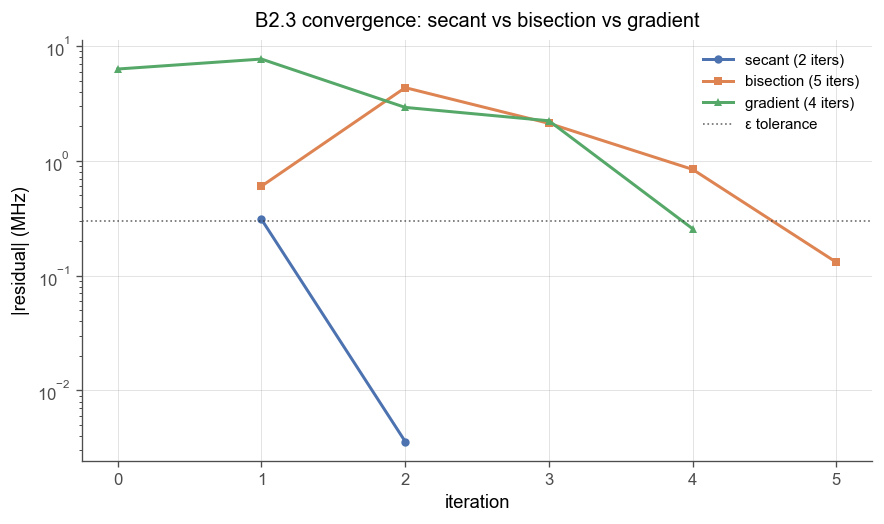

secant   :  2 iters, residual=+0.0035 MHz, converged=True
bisection:  5 iters, residual=+0.1304 MHz, converged=True
gradient :  4 iters, residual=-0.2556 MHz, converged=True

secant 2 步（超线性，需预括号 V_a/V_b）；bisection 5 步（稳健，括号按 log₂ 收缩）；gradient 4 步（无需预括号，只要 V_seed）。三者均收敛到 ε 内。


In [17]:
# 根设在 flux=0.028；搜索区间 [0.008, 0.05]（中点 0.029≠根），避开甜点
f_tgt3 = make_qubit(flux=0.028).frequency
eps3 = TWO_PI * 3e-4
common = dict(qubit=q0, f_target=f_tgt3, measure_method="ramsey",
              epsilon_f=eps3, max_iter=15,
              tau_list=TAU_B, t_rabi=TR_B, t_global=TG_RAMSEY)

runs = {}
for sm in ("secant", "bisection", "gradient"):
    kw = dict(common, step_method=sm)
    if sm == "gradient":
        kw["V_seed"] = 0.012
    else:
        kw["V_a"], kw["V_b"] = 0.008, 0.05
    runs[sm] = SinglePointFrequencyCalibration(**kw).calibrate()

fig, ax = plt.subplots(figsize=(7.5, 4.5))
markers = {"secant": "o-", "bisection": "s-", "gradient": "^-"}
colors = {"secant": PALETTE[0], "bisection": PALETTE[1], "gradient": PALETTE[2]}
for sm, cal in runs.items():
    h = cal.fit_params["history"]
    it = [d["iter"] for d in h]
    r = [abs(to_MHz(d["residual"])) + 1e-4 for d in h]
    ax.semilogy(it, r, markers[sm], color=colors[sm],
                label=f"{sm} ({cal.fit_params['n_iter']} iters)")
ax.axhline(to_MHz(eps3), color=C_REF, ls=":", lw=1, alpha=0.7, label="ε tolerance")
ax.set(xlabel="iteration", ylabel="|residual| (MHz)",
       title="B2.3 convergence: secant vs bisection vs gradient")
ax.legend(fontsize=9)
fig.tight_layout(); plt.show()

for sm, cal in runs.items():
    fp = cal.fit_params
    print(f"{sm:9s}: {fp['n_iter']:2d} iters, residual={to_MHz(fp['residual']):+.4f} MHz, "
          f"converged={fp['converged']}")
n_sec, n_bis, n_grad = (runs[s].fit_params["n_iter"] for s in ("secant", "bisection", "gradient"))
print(f"\nsecant {n_sec} 步（超线性，需预括号 V_a/V_b）；bisection {n_bis} 步（稳健，"
      f"括号按 log₂ 收缩）；gradient {n_grad} 步（无需预括号，只要 V_seed）。三者均收敛到 ε 内。")

# 第三部分 · 预失真

AWG 发出的电压波形，经控制线（线缆、滤波器、bias-tee）到达芯片时会被**畸变**：理想方波会拖出一条指数尾巴。预失真（predistortion）是**预先给 AWG 波形做逆变换**，使它过控制线后还原成目标波形。本部分围绕 `sqc.hardware.*` /
`sqc.calibration.waveform` / `sqc.workflows.predistortion_validation`，走一条主线：

- **C1 问题** —— 建畸变模型 + 控制线，看目标波形过线后的拖尾长什么样。
- **C2 解析路径** —— 已知传函时一键验证 + 手动三步（测传函 → 设计逆滤波 → 施加），  改善可至机器精度（理论上限）。
- **C3 真实标定路径** —— 用 Cryoscope 量子仿真测阶跃响应，拟合传函再求逆，  改善落到真实的 10–100× 量级。

控制线是**线性时不变（LTI）系统**，用传递函数 $H(\omega)$ 或阶跃响应 $s(t)$ 描述。预失真在 AWG 前级联逆滤波器 $H^{-1}$，使总传函 $H\,H^{-1}=1$。对指数型畸变，逆滤波器有解析 IIR 形式；一般畸变走频域反演 $H^{-1}=\bar H/(|H|^2+\varepsilon^2)$。两种途径都由 `PredistortionDesigner` 统一提供。

## C1. 畸变与控制线：问题长什么样

先用真实 API 把“畸变”可视化。`SingleExponentialDistortion(amplitude, tau)` 描述一条幅度 $A$、时间常数 $\tau$ 的指数拖尾（阶跃响应 $s(t)=1-A\,e^{-t/\tau}$，见
{doc}`../building_blocks/hardware`）；`ControlLine` 把它挂在 AWG→qubit 的链路上。把一段 0.05 $\Phi_0$ 的目标平台送进控制线，看芯片端实际收到的波形：起点欠冲、需数个 $\tau$ 才整定到终值。

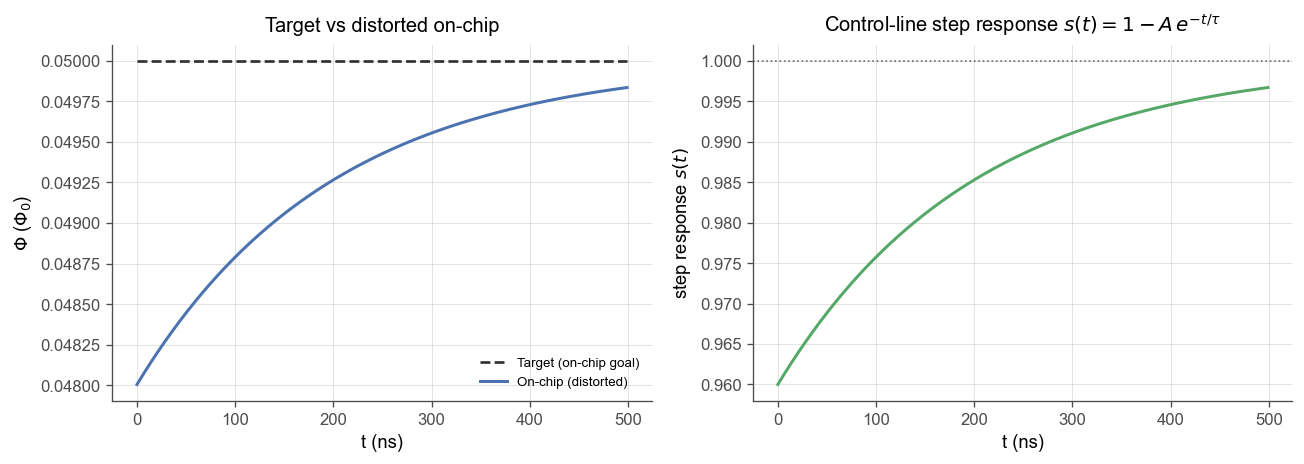

片上起点 0.0480 vs 目标 0.0500 （欠冲 4.0%），终点 0.04984；拖尾时间常数 tau=200 ns，需数个 tau 才整定。


In [18]:
from sqc.control.waveform import Waveform
from sqc.hardware.distortion import SingleExponentialDistortion
from sqc.hardware.control_line import ControlLine

# 目标片上波形：一段 0.05 Phi_0 的平台（我们希望芯片上看到的样子）
dt = 1.0                                   # ns
t = np.arange(0, 500, dt)
target = Waveform(t_list=t, samples=np.ones_like(t) * 0.05)

# 真值畸变：幅度 0.04、时间常数 200 ns 的单指数尾巴（Cryoscope 常见的慢磁通畸变）
distortion = SingleExponentialDistortion(amplitude=0.04, tau=200.0)

# 控制线：把畸变挂上，把目标波形送进去，看芯片端实际收到什么
line = ControlLine(name="Z0", kind="z", source="AWG0", target="Q0",
                   transfer_function=distortion)
on_chip = line.apply(target)               # 未预畸变时的片上波形（带拖尾）

# 阶跃响应 s(t)=1-A e^{-t/tau}：畸变本身的“指纹”
step = distortion.step_response(t)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(t, target.samples, "--", color=C_REF, lw=1.6, label="Target (on-chip goal)")
axes[0].plot(t, on_chip.samples, color=C_DATA, lw=1.8, label="On-chip (distorted)")
axes[0].set(xlabel="t (ns)", ylabel=r"$\Phi$ ($\Phi_0$)",
            title="Target vs distorted on-chip")
axes[0].legend(fontsize=8)
axes[1].plot(t, step, color=PALETTE[2], lw=1.8)
axes[1].axhline(1.0, color=C_REF, ls=":", lw=1, alpha=0.7)
axes[1].set(xlabel="t (ns)", ylabel="step response $s(t)$",
            title=r"Control-line step response $s(t)=1-A\,e^{-t/\tau}$")
fig.tight_layout(); plt.show()

undershoot = (target.samples[0] - on_chip.samples[0]) / target.samples[0]
print(f"片上起点 {on_chip.samples[0]:.4f} vs 目标 {target.samples[0]:.4f} "
      f"（欠冲 {undershoot*100:.1f}%），终点 {on_chip.samples[-1]:.5f}；"
      f"拖尾时间常数 tau={distortion.tau:.0f} ns，需数个 tau 才整定。")

## C2. 解析路径：一键验证 + 手动三步

`PredistortionValidationWorkflow` 一次调用跑完整条验证管道（注入畸变 → 测传函 →设计逆滤波 → 施加预失真 → 复测 → 算改善），返回 `target` / `on_chip_uncorrected` /
`on_chip_corrected` / `awg_predistorted` / `inverse_model` / `measured_model` /
`metrics` 七个字段。也可手动拆三步看各步作用：`WaveformCalibration.to_distortion_model()`拟合出**正向**畸变模型 → `PredistortionDesigner.design()` 求**逆**滤波器 →`apply_to_waveform()` 把预失真施加到目标，得到该送进 AWG 的波形（注意其“预加重”过冲）。

> 本例走**解析路径**（不传 `qubit`/`measurement_protocol`）：直接对真值畸变的阶跃> 响应拟合再解析求逆，相当于已知 $H$ 的精确形式，补偿后 RMSE 可低至机器精度> （$\sim10^{-15}$）。这是**解析上限，不代表真实系统**——真实收益见 C3。

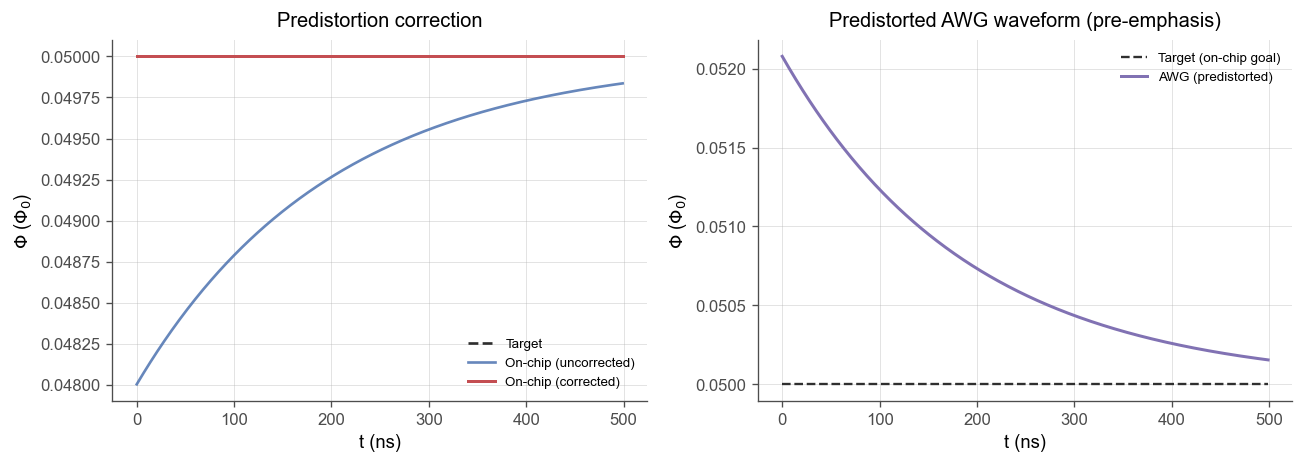

补偿前 RMSE = 8.914e-04
补偿后 RMSE = 1.618e-15
改善倍数    = 5.51e+11x
整定时间：补偿前 138 ns -> 补偿后 0 ns
注：解析路径直接对真值畸变求逆，改善可至机器精度 —— 是理论上限，不代表真实系统。


In [19]:
from sqc.calibration.waveform import WaveformCalibration, PredistortionDesigner
from sqc.workflows import PredistortionValidationWorkflow

# --- 一键验证：注入畸变 -> 测传函 -> 设计逆滤波 -> 施加 -> 复测 -> 算改善 ---
wf = PredistortionValidationWorkflow(target_waveform=target, true_distortion=distortion)
res = wf.run()
m = res["metrics"]

# --- 也可手动拆三步，看“测传函 -> 设计逆 -> 施加”各步在做什么 ---
wf_cal = WaveformCalibration(distortion=distortion, fit_type="single_exp")
fwd_model = wf_cal.to_distortion_model()             # 拟合出的“正向”畸变模型
designer = PredistortionDesigner(method="auto")
inverse = designer.design(fwd_model, dt=dt)          # 逆滤波器 H^{-1}
awg_wave = inverse.apply_to_waveform(target)         # 该送进 AWG 的预畸变波形

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(t, res["target"].samples, "--", color=C_REF, lw=1.6, label="Target")
axes[0].plot(t, res["on_chip_uncorrected"].samples, color=C_DATA, lw=1.6,
             alpha=0.85, label="On-chip (uncorrected)")
axes[0].plot(t, res["on_chip_corrected"].samples, color=C_REC, lw=1.8,
             label="On-chip (corrected)")
axes[0].set(xlabel="t (ns)", ylabel=r"$\Phi$ ($\Phi_0$)", title="Predistortion correction")
axes[0].legend(fontsize=8)
axes[1].plot(t, target.samples, "--", color=C_REF, lw=1.4, label="Target (on-chip goal)")
axes[1].plot(t, awg_wave.samples, color=PALETTE[4], lw=1.8, label="AWG (predistorted)")
axes[1].set(xlabel="t (ns)", ylabel=r"$\Phi$ ($\Phi_0$)",
            title="Predistorted AWG waveform (pre-emphasis)")
axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

print(f"补偿前 RMSE = {m['rmse_uncorrected']:.3e}")
print(f"补偿后 RMSE = {m['rmse_corrected']:.3e}")
print(f"改善倍数    = {m['improvement_factor']:.2e}x")
print(f"整定时间：补偿前 {m['settling_uncorrected_ns']:.0f} ns -> "
      f"补偿后 {m['settling_corrected_ns']:.0f} ns")
print("注：解析路径直接对真值畸变求逆，改善可至机器精度 —— 是理论上限，不代表真实系统。")

## C3. 真实标定路径 —— Cryoscope 量子仿真

真实标定测不到解析传函，得**用量子仪器测阶跃响应**。给 `PredistortionValidationWorkflow`传 `qubit` 与 `measurement_protocol="cryoscope"`，即通过量子仿真（而非解析公式）测控制线阶跃响应，再拟合成畸变模型、求逆。

> Cryoscope 在**甜点 flux=0** 工作最佳（使 $\varphi(h)$ 对称、色散关系可正确反演）——> 这与波形重建里 A4 用敏感点 flux=0.25 不同，是协议本身的要求。偏离甜点会让阶跃响应> 被 qubit 自身色散污染、拟合发散。

拟合精度有限、逆滤波非理想，改善倍数因而落到有限量级（典型 10–100×），远低于 C2 的解析上限——但这才反映实际预失真的真实收益。下面把两者并排对比。

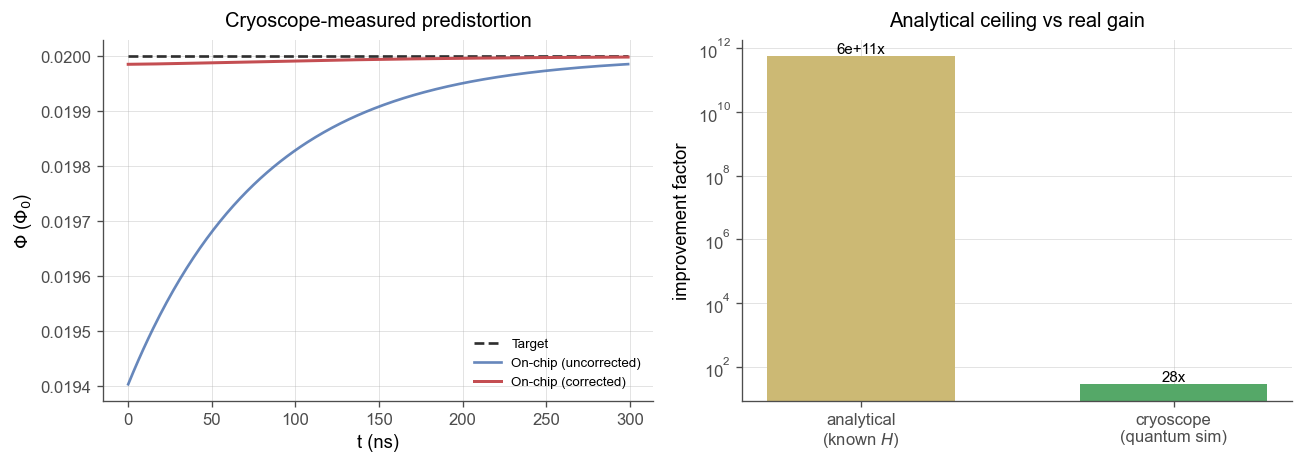

真值畸变: amp=0.03, tau=80 ns
Cryoscope 拟合: amp=0.029, tau=78.4 ns
补偿前 RMSE=2.190e-04 -> 补偿后 RMSE=7.748e-06
改善倍数：解析上限 5.5e+11x  vs  真实 cryoscope 28.3x
真实标定拟合精度有限、逆滤波非理想，改善落到有限量级（此处约 28x），更能反映实际预畸变的收益。


In [20]:
import contextlib, io as _io

# 真值畸变（换一组更贴近慢磁通拖尾的参数）与目标平台
dist_r = SingleExponentialDistortion(amplitude=0.03, tau=80.0)
t_r = np.arange(0, 300, dt)
target_r = Waveform(t_list=t_r, samples=np.ones_like(t_r) * 0.02)

# Cryoscope 量子仿真测阶跃：qubit 在【甜点 flux=0】工作（cryoscope 的正确工作点，
# 使 phi(h) 对称、色散关系可正确反演）。协议驱动路径的实验会向 stdout 打诊断，
# 用 redirect_stdout 收掉以保持输出干净。
q_cryo = make_qubit(flux=0.0, n_levels=3)
wf_real = PredistortionValidationWorkflow(
    target_waveform=target_r, true_distortion=dist_r,
    qubit=q_cryo, measurement_protocol="cryoscope",
)
with contextlib.redirect_stdout(_io.StringIO()):
    res_r = wf_real.run()
mr = res_r["metrics"]
fp = mr["calibration_fit_type"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(t_r, res_r["target"].samples, "--", color=C_REF, lw=1.6, label="Target")
axes[0].plot(t_r, res_r["on_chip_uncorrected"].samples, color=C_DATA, lw=1.6,
             alpha=0.85, label="On-chip (uncorrected)")
axes[0].plot(t_r, res_r["on_chip_corrected"].samples, color=C_REC, lw=1.8,
             label="On-chip (corrected)")
axes[0].set(xlabel="t (ns)", ylabel=r"$\Phi$ ($\Phi_0$)",
            title="Cryoscope-measured predistortion")
axes[0].legend(fontsize=8)
labels = ["analytical\n(known $H$)", "cryoscope\n(quantum sim)"]
vals = [m["improvement_factor"], mr["improvement_factor"]]
bars = axes[1].bar(labels, vals, color=[PALETTE[6], PALETTE[2]], width=0.6)
axes[1].set_yscale("log")
axes[1].set(ylabel="improvement factor", title="Analytical ceiling vs real gain")
for b, v in zip(bars, vals):
    axes[1].text(b.get_x() + b.get_width() / 2, v,
                 f"{v:.0e}x" if v > 1e3 else f"{v:.0f}x",
                 ha="center", va="bottom", fontsize=9)
fig.tight_layout(); plt.show()

print(f"真值畸变: amp={dist_r.amplitude}, tau={dist_r.tau:.0f} ns")
print(f"Cryoscope 拟合: amp={fp['amplitude']:.3f}, tau={fp['tau']:.1f} ns")
print(f"补偿前 RMSE={mr['rmse_uncorrected']:.3e} -> 补偿后 RMSE={mr['rmse_corrected']:.3e}")
print(f"改善倍数：解析上限 {m['improvement_factor']:.1e}x  vs  真实 cryoscope {mr['improvement_factor']:.1f}x")
print("真实标定拟合精度有限、逆滤波非理想，改善落到有限量级（此处约 {:.0f}x），"
      "更能反映实际预畸变的收益。".format(mr['improvement_factor']))